# Buổi 6 — Sự lan truyền ngược (backpropagation)

## Ví dụ thực tế: phát hiện bất thường giữa tải CPU và quạt tản nhiệt

Notebook này là phần thực hành của bài giảng *Bài 10 — Sự lan truyền ngược*. Mạch đi
của notebook giống mạch của buổi 5: **đọc công thức → chạy code → đối chiếu số liệu in
ra → đọc phần giải thích**.

Điểm mới so với buổi 5: thay vì một nơ-ron Adaline, ta dùng mạng `2 → 2 → 1` và phải
truyền sai số **ngược** từ tầng ra về tầng ẩn.

Nội dung:

- **Bảng thuật ngữ Anh – Việt** — tra nhanh, dùng xuyên suốt notebook.
1. Bài toán CPU – quạt tản nhiệt và vì sao nó chính là XOR.
2. Kiểm chứng bằng code: một Perceptron không giải được XOR.
3. Kiến trúc `2 → 2 → 1` và hàm sigmoid.
4. **Lan truyền xuôi (forward propagation)**: trực giác, tên gọi từng đại lượng, vì sao
   phải lưu giá trị trung gian, và một lượt tính tay đối chiếu với bài giảng.
5. **Thuật toán lan truyền ngược (backpropagation)**: bài toán gán trách nhiệm sai số,
   quy tắc "upstream × local", bảy bước thuật toán, và các lỗi thường gặp.
6. Backward tại tầng ra — đối chiếu từng con số.
7. Backward tại tầng ẩn — đối chiếu từng con số.
8. Cập nhật tham số và kiểm tra loss có giảm thật không.
9. Kiểm tra gradient bằng phương pháp số (gradient checking).
10. Huấn luyện đủ 4 mẫu, vẽ loss curve.
11. Tầng ẩn đã học được biểu diễn gì.
12. Thí nghiệm learning rate, số nơ-ron ẩn.
13. Thử mô hình trên input liên tục.
14. Bài tập, câu hỏi thảo luận, giới hạn của ví dụ.

## Bảng thuật ngữ Anh – Việt

Tài liệu về mạng nơ-ron trộn lẫn tiếng Anh và tiếng Việt rất nhiều: giáo trình viết
"lan truyền ngược", code và thư viện lại viết `backward`. Bảng dưới đây ghép **thuật ngữ
tiếng Anh – tiếng Việt – cách hình dung**, để khi đọc bất kỳ tài liệu nào bạn cũng nhận
ra mình đang ở bước nào.

### Kiến trúc mạng

| English | Tiếng Việt | Cách hình dung |
|---|---|---|
| neuron / unit / node | nơ-ron / đơn vị / nút | một "máy tính con": nhận nhiều số, trả về một số |
| input layer | tầng vào | cửa nhận dữ liệu thô (tải CPU, tốc độ quạt) |
| hidden layer | tầng ẩn | các trạm trung gian, không ai gán nhãn cho chúng |
| output layer | tầng ra | nơi đưa ra câu trả lời cuối cùng |
| weight ($w$) | trọng số | "mức độ quan trọng" của một tín hiệu đầu vào |
| bias ($b$) | độ lệch / thiên lệch | ngưỡng dễ/khó bật của nơ-ron, không phụ thuộc input |
| parameter ($\theta$) | tham số | tên gọi chung cho tất cả weight và bias |
| activation function | hàm kích hoạt | van phi tuyến; không có nó, nhiều tầng cũng vô nghĩa |
| MLP (multi-layer perceptron) | Perceptron nhiều tầng | nhiều tầng nơ-ron xếp liên tiếp, nối đầy đủ |
| architecture `2 → 2 → 1` | kiến trúc `2 → 2 → 1` | 2 input, 2 nơ-ron ẩn, 1 đầu ra |

### Lan truyền xuôi

| English | Tiếng Việt | Cách hình dung |
|---|---|---|
| forward propagation / forward pass | lan truyền xuôi / lượt xuôi | dữ liệu chảy từ input đến dự đoán |
| weighted sum / net input / pre-activation ($z$) | tổng có trọng số / đầu vào thuần | điểm số thô **trước khi** qua hàm kích hoạt |
| activation ($a$) | giá trị kích hoạt | kết quả **sau khi** qua hàm kích hoạt |
| prediction ($\hat y$) | dự đoán | đầu ra của tầng cuối; đọc là "y mũ" hoặc "y hat" |
| ground truth / label / target ($y$, $t$) | nhãn đúng / giá trị đích | câu trả lời đúng mà ta muốn mạng học |
| computational graph | đồ thị tính toán | sơ đồ ai-phụ-thuộc-ai giữa các phép tính |
| cache (saved activations) | bộ nhớ đệm giá trị trung gian | các số của lượt xuôi được giữ lại để lượt ngược dùng |

### Đo sai số

| English | Tiếng Việt | Cách hình dung |
|---|---|---|
| loss / cost / objective function ($L$) | hàm mất mát / hàm chi phí | một con số duy nhất: "mạng đang sai bao nhiêu" |
| MSE (mean squared error) | trung bình bình phương sai số | phạt sai số theo bình phương, trơn và dễ lấy đạo hàm |
| BCE (binary cross-entropy) | entropy chéo nhị phân | loss chuẩn cho bài toán hai lớp với sigmoid |
| error ($e$) | sai số | khoảng chênh giữa dự đoán và nhãn |

### Lan truyền ngược

| English | Tiếng Việt | Cách hình dung |
|---|---|---|
| backpropagation / backward pass | lan truyền ngược / lượt ngược | sai số chảy **ngược** từ loss về từng trọng số |
| credit assignment problem | bài toán gán trách nhiệm | "ai đã gây ra sai số này, và bao nhiêu phần?" |
| chain rule | quy tắc dây chuyền / quy tắc chuỗi | nhân các đạo hàm dọc theo đường đi |
| gradient ($\partial L/\partial \theta$) | gradient / độ dốc | vector chỉ hướng loss **tăng** nhanh nhất |
| partial derivative | đạo hàm riêng | thay đổi loss khi nhúc nhích **một** tham số |
| upstream gradient | gradient truyền đến | tín hiệu lỗi nhận từ phía sau (phía loss) |
| local gradient / local derivative | đạo hàm cục bộ | đạo hàm của **riêng** phép toán tại nút đó |
| delta ($\delta$), error signal | delta, tín hiệu lỗi | $\partial L/\partial z$ — lỗi quy về đầu vào thuần của nơ-ron |
| elementwise product ($\odot$) | nhân theo từng phần tử | nhân từng cặp phần tử cùng vị trí, không phải nhân ma trận |
| transpose ($\mathbf{W}^\top$) | chuyển vị | đổi dòng thành cột, để lỗi đi đúng chiều ngược |

### Cập nhật tham số

| English | Tiếng Việt | Cách hình dung |
|---|---|---|
| gradient descent | hạ gradient / xuống dốc theo gradient | đi ngược hướng dốc để tụt xuống đáy thung lũng loss |
| learning rate ($\eta$) | tốc độ học | độ dài mỗi bước chân; quá dài thì bước quá đà |
| optimizer | bộ tối ưu | luật quyết định bước đi (SGD, Momentum, Adam...) |
| epoch | epoch / lượt học | một lần đi qua **toàn bộ** tập dữ liệu |
| batch / mini-batch / SGD | lô / lô nhỏ / hạ gradient ngẫu nhiên | cập nhật sau toàn bộ dữ liệu / sau một nhóm / sau từng mẫu |
| convergence | sự hội tụ | loss thôi giảm đáng kể, mô hình đã ổn định |

### Các vấn đề thường gặp

| English | Tiếng Việt | Cách hình dung |
|---|---|---|
| vanishing gradient | gradient tiêu biến | gradient nhỏ dần qua từng tầng đến mức gần bằng 0 |
| exploding gradient | gradient bùng nổ | gradient lớn dần đến mức tham số nhảy loạn |
| saturation | bão hoà | sigmoid bị đẩy về sát 0 hoặc 1, đạo hàm gần bằng 0 |
| gradient checking | kiểm tra gradient | so gradient công thức với gradient tính bằng sai phân |
| overfitting | quá khớp | thuộc lòng dữ liệu huấn luyện, dự đoán kém trên dữ liệu mới |
| decision boundary | ranh giới quyết định | đường/mặt chia không gian thành các lớp |

> Ba từ dễ lẫn nhất, cần nhớ chính xác:
>
> - **Backpropagation** = *thuật toán tính gradient*. Nó chỉ tính, **không** sửa tham số.
> - **Gradient descent / optimizer** = *luật dùng gradient để sửa tham số*.
> - **Delta ($\delta$)** = *tín hiệu lỗi tại đầu vào thuần của một nơ-ron*, không phải gradient của trọng số.

## 1. Bối cảnh và dữ liệu

Một máy tính được theo dõi bằng hai tín hiệu nhị phân:

- $x_1$: tải CPU có cao không? (`0` = thấp, `1` = cao)
- $x_2$: quạt tản nhiệt có quay nhanh không? (`0` = chậm, `1` = nhanh)
- $y$: có cần phát cảnh báo bất thường không? (`0` = bình thường, `1` = cảnh báo)

Lập luận nghiệp vụ:

| Tải CPU | Quạt | Cảnh báo | Diễn giải |
|---:|---:|---:|---|
| 0 | 0 | 0 | CPU thấp, quạt chậm — bình thường |
| 0 | 1 | 1 | CPU thấp, quạt nhanh — bất thường, có thể quạt/cảm biến lỗi |
| 1 | 0 | 1 | CPU cao, quạt chậm — bất thường, nguy cơ quá nhiệt |
| 1 | 1 | 0 | CPU cao, quạt nhanh — bình thường, quạt phản ứng đúng |

Quan hệ này chính là XOR:

$$
y = x_1 \operatorname{XOR} x_2
$$

Nói bằng ngôn ngữ đời sống: **hệ thống cảnh báo khi tải CPU và phản ứng của quạt không đồng bộ.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# X = [tải CPU, tốc độ quạt]
X = np.array([
    [0., 0.],   # CPU thấp, quạt chậm  -> bình thường
    [0., 1.],   # CPU thấp, quạt nhanh -> bất thường
    [1., 0.],   # CPU cao,  quạt chậm  -> bất thường
    [1., 1.],   # CPU cao,  quạt nhanh -> bình thường
])

# y = nhãn cảnh báo, giữ dạng cột (4, 1) để khớp với đầu ra của mạng
y = np.array([[0.], [1.], [1.], [0.]])

bang = pd.DataFrame({
    "x1_tai_cpu": X[:, 0],
    "x2_quat": X[:, 1],
    "y_canh_bao": y[:, 0],
    "dien_giai": [
        "CPU thấp, quạt chậm — bình thường",
        "CPU thấp, quạt nhanh — bất thường",
        "CPU cao, quạt chậm — bất thường",
        "CPU cao, quạt nhanh — bình thường",
    ],
})
display(bang)

print("X.shape =", X.shape, "| y.shape =", y.shape)
print("Kiểm tra y có đúng là XOR:", np.array_equal(y[:, 0], np.logical_xor(X[:, 0], X[:, 1]).astype(float)))

,x1_tai_cpu,x2_quat,y_canh_bao,dien_giai
0,0.0,0.0,0.0,"CPU thấp, quạt chậm — bình thường"
1,0.0,1.0,1.0,"CPU thấp, quạt nhanh — bất thường"
2,1.0,0.0,1.0,"CPU cao, quạt chậm — bất thường"
3,1.0,1.0,0.0,"CPU cao, quạt nhanh — bình thường"


X.shape = (4, 2) | y.shape = (4, 1)
Kiểm tra y có đúng là XOR: True


Hai cột đầu là **feature**, cột `y_canh_bao` là **nhãn**. Dữ liệu chỉ có 4 dòng nên ta
có thể kiểm tra từng con số bằng tay — đây là lý do XOR được dùng làm ví dụ kinh điển
cho backpropagation.

Chú ý `y` được giữ ở dạng `(4, 1)` chứ không phải `(4,)`. Giữ đúng shape ngay từ đầu sẽ
tránh lỗi broadcasting khi tính `y_hat - y` ở phần sau.

## 2. Vì sao một Perceptron không đủ?

Vẽ bốn điểm lên mặt phẳng: hai điểm cảnh báo `(0,1)` và `(1,0)` nằm ở hai góc đối diện,
hai điểm bình thường `(0,0)` và `(1,1)` cũng nằm ở hai góc đối diện. Không có đường
thẳng nào tách được hai nhóm.

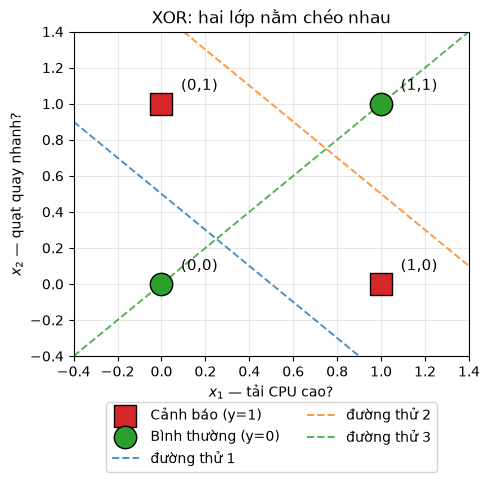

In [2]:
fig, ax = plt.subplots(figsize=(5, 5))

mask = y[:, 0] == 1
ax.scatter(X[mask, 0], X[mask, 1], s=260, marker="s", c="#d62728",
           edgecolors="black", zorder=3, label="Cảnh báo (y=1)")
ax.scatter(X[~mask, 0], X[~mask, 1], s=260, marker="o", c="#2ca02c",
           edgecolors="black", zorder=3, label="Bình thường (y=0)")

for (x1, x2), t in zip(X, y[:, 0]):
    ax.annotate(f"({x1:.0f},{x2:.0f})", (x1, x2),
                textcoords="offset points", xytext=(14, 10), fontsize=11)

# Ba đường thẳng thử nghiệm: không đường nào tách đúng
xs = np.linspace(-0.4, 1.4, 50)
for k, (a, b_, label) in enumerate([
    (-1.0, 0.5, "đường thử 1"),
    (-1.0, 1.5, "đường thử 2"),
    (1.0, 0.0, "đường thử 3"),
]):
    ax.plot(xs, a * xs + b_, "--", lw=1.4, alpha=0.8, label=label)

ax.set_xlim(-0.4, 1.4)
ax.set_ylim(-0.4, 1.4)
ax.set_xlabel("$x_1$ — tải CPU cao?")
ax.set_ylabel("$x_2$ — quạt quay nhanh?")
ax.set_title("XOR: hai lớp nằm chéo nhau")
ax.grid(alpha=0.3)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
plt.tight_layout()
plt.show()

Thay vì chỉ nhìn hình, ta để máy tự chứng minh: huấn luyện một Perceptron (hàm bước,
quy tắc học của buổi 4) trên đúng bốn mẫu này và xem độ chính xác tốt nhất đạt được.

In [3]:
def perceptron_xor(so_epoch=200, eta=0.1, seed=0):
    # Huấn luyện một Perceptron trên XOR, trả về độ chính xác tốt nhất từng đạt
    rng = np.random.default_rng(seed)
    w = rng.normal(0, 0.5, size=2)
    b = 0.0
    t = y[:, 0]
    acc_tot_nhat = 0.0

    for _ in range(so_epoch):
        for xi, ti in zip(X, t):
            net = w @ xi + b
            y_hat = 1.0 if net >= 0 else 0.0
            e = ti - y_hat           # quy tắc Perceptron: sai thì sửa
            w += eta * e * xi
            b += eta * e
        du_doan = (X @ w + b >= 0).astype(float)
        acc_tot_nhat = max(acc_tot_nhat, (du_doan == t).mean())

    du_doan = (X @ w + b >= 0).astype(float)
    return w, b, du_doan, acc_tot_nhat


for seed in range(5):
    w_p, b_p, du_doan, acc = perceptron_xor(seed=seed)
    print(f"seed={seed} | dự đoán = {du_doan} | nhãn = {y[:, 0]} "
          f"| accuracy tốt nhất = {acc:.2f}")

print("\nNhãn đúng cần đạt:", y[:, 0], "-> accuracy 1.00")

seed=0 | dự đoán = [1. 0. 0. 0.] | nhãn = [0. 1. 1. 0.] | accuracy tốt nhất = 0.50
seed=1 | dự đoán = [1. 1. 0. 0.] | nhãn = [0. 1. 1. 0.] | accuracy tốt nhất = 0.50
seed=2 | dự đoán = [1. 0. 0. 0.] | nhãn = [0. 1. 1. 0.] | accuracy tốt nhất = 0.50
seed=3 | dự đoán = [1. 0. 0. 0.] | nhãn = [0. 1. 1. 0.] | accuracy tốt nhất = 0.75
seed=4 | dự đoán = [1. 0. 0. 0.] | nhãn = [0. 1. 1. 0.] | accuracy tốt nhất = 0.50

Nhãn đúng cần đạt: [0. 1. 1. 0.] -> accuracy 1.00


Với mọi khởi tạo, Perceptron một tầng chỉ đạt 0.50–0.75 (đúng 2/4 hoặc 3/4 mẫu) và
**không bao giờ** đạt 1.00. Lý do không nằm ở learning rate hay số epoch mà nằm ở **năng
lực biểu diễn**: một Perceptron chỉ tạo được **một** ranh giới tuyến tính, còn XOR cần
ranh giới phi tuyến.

Cách khắc phục: thêm một **tầng ẩn** để biến đổi dữ liệu sang không gian mới, nơi hai
lớp trở nên tách được tuyến tính. Phần 9 sẽ cho thấy tầng ẩn thực sự làm điều đó.

## 3. Kiến trúc MLP `2 → 2 → 1` và hàm sigmoid

- Tầng vào: 2 giá trị — tải CPU, tốc độ quạt.
- Tầng ẩn: 2 nơ-ron $h_1, h_2$.
- Tầng ra: 1 nơ-ron, cho điểm số cảnh báo trong khoảng $(0, 1)$.

Tham số:

$$
\mathbf{W}^{(1)} \in \mathbb{R}^{2\times 2}, \quad
\mathbf{b}^{(1)} \in \mathbb{R}^{2\times 1}, \quad
\mathbf{W}^{(2)} \in \mathbb{R}^{1\times 2}, \quad
b^{(2)} \in \mathbb{R}
$$

Hàm kích hoạt sigmoid và đạo hàm:

$$
\sigma(z) = \frac{1}{1+e^{-z}}, \qquad
\sigma'(z) = \sigma(z)\bigl(1-\sigma(z)\bigr) = a(1-a)
$$

Công thức $\sigma'(z) = a(1-a)$ rất tiện: khi đã có activation $a$ từ lượt forward, ta
tính được đạo hàm mà không cần tính lại $z$. Đây chính là lý do backpropagation phải
**lưu lại** các giá trị trung gian của lượt forward.

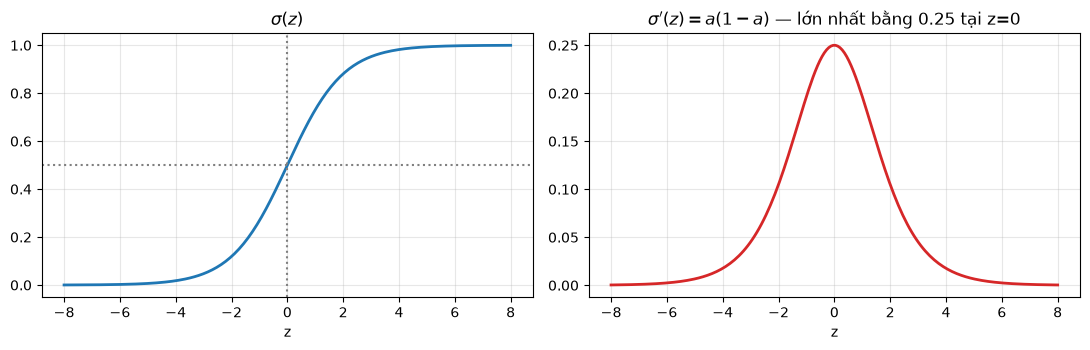

sigmoid(0.2) = 0.54983
sigmoid(0.1) = 0.52498
đạo hàm lớn nhất của sigmoid = 0.25


In [4]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid_grad_tu_activation(a):
    # Đạo hàm sigmoid khi đã biết activation a = sigmoid(z)
    return a * (1.0 - a)


z_demo = np.linspace(-8, 8, 200)
a_demo = sigmoid(z_demo)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(z_demo, a_demo, lw=2)
axes[0].axhline(0.5, ls=":", c="gray")
axes[0].axvline(0.0, ls=":", c="gray")
axes[0].set_title(r"$\sigma(z)$")
axes[0].set_xlabel("z")
axes[0].grid(alpha=0.3)

axes[1].plot(z_demo, sigmoid_grad_tu_activation(a_demo), lw=2, c="#d62728")
axes[1].set_title(r"$\sigma'(z) = a(1-a)$ — lớn nhất bằng 0.25 tại z=0")
axes[1].set_xlabel("z")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("sigmoid(0.2) =", round(float(sigmoid(0.2)), 5))
print("sigmoid(0.1) =", round(float(sigmoid(0.1)), 5))
print("đạo hàm lớn nhất của sigmoid =", round(float(sigmoid_grad_tu_activation(sigmoid(0.0))), 5))

Hai con số `sigmoid(0.2) ≈ 0.54983` và `sigmoid(0.1) ≈ 0.52498` sẽ xuất hiện lại trong
phần tính tay ngay dưới đây.

Đồ thị bên phải cũng giải thích một hiện tượng thực tế: đạo hàm sigmoid không bao giờ
vượt 0.25, nên khi mạng sâu, gradient bị nhân nhiều lần với số nhỏ hơn 0.25 và **tiêu
biến** dần (vanishing gradient). Đó là động lực để các mạng hiện đại dùng ReLU.

## 4. Lan truyền xuôi (forward propagation)

### 4.1 Trực giác: một dây chuyền sản xuất

Hãy hình dung mạng nơ-ron như một **dây chuyền sản xuất**. Nguyên liệu đầu vào là hai
con số đo được từ máy tính; mỗi trạm trên dây chuyền gia công một chút rồi chuyển sang
trạm sau; cuối dây chuyền cho ra một sản phẩm là con số dự đoán; và cuối cùng bộ phận
kiểm định (loss) so sánh sản phẩm với bản mẫu để cho điểm sai lệch.

**Lan truyền xuôi (forward propagation)** chính là một lượt chạy của dây chuyền đó, từ
nguyên liệu đến điểm kiểm định:

```text
    x            z⁽¹⁾           a⁽¹⁾          z⁽²⁾          ŷ            L
 ┌───────┐   ┌──────────┐   ┌────────┐   ┌──────────┐   ┌───────┐   ┌────────┐
 │ input │──▶│ W⁽¹⁾x+b⁽¹⁾│──▶│ σ(z⁽¹⁾) │──▶│ W⁽²⁾a+b⁽²⁾│──▶│ σ(z⁽²⁾)│──▶│ ½(ŷ−y)²│
 └───────┘   └──────────┘   └────────┘   └──────────┘   └───────┘   └────────┘
  tải CPU     tổng có        giá trị      tổng có        dự đoán     điểm sai
  + quạt      trọng số       kích hoạt    trọng số                    lệch
              (tầng ẩn)      (tầng ẩn)    (tầng ra)

 ──────────────────────  chiều LAN TRUYỀN XUÔI (forward)  ──────────────────────▶
```

Sơ đồ trên gọi là **đồ thị tính toán (computational graph)**. Nó quan trọng vì sang phần
lan truyền ngược, ta sẽ đi đúng sơ đồ này nhưng **theo chiều ngược lại**.

### 4.2 Tên gọi chính xác của từng đại lượng

Mỗi nơ-ron làm đúng **hai** việc, và hai việc này có tên riêng — đây là chỗ sinh viên hay
gộp lại thành một nên sau đó lẫn lộn khi lấy đạo hàm:

| Bước | Ký hiệu | English | Tiếng Việt | Ý nghĩa |
|---|---|---|---|---|
| 1 | $z = \mathbf{w}^\top\mathbf{x} + b$ | net input / weighted sum / pre-activation | đầu vào thuần / tổng có trọng số | cân đo các tín hiệu vào, **chưa** qua van phi tuyến |
| 2 | $a = \sigma(z)$ | activation | giá trị kích hoạt | đưa $z$ qua van sigmoid, ép về khoảng $(0,1)$ |

Áp dụng cho mạng `2 → 2 → 1`, lượt xuôi gồm đúng bốn phép tính rồi đến loss:

$$
\underbrace{\mathbf{z}^{(1)} = \mathbf{W}^{(1)}\mathbf{x} + \mathbf{b}^{(1)}}_{\text{(1) tổng có trọng số ở tầng ẩn}}
\qquad
\underbrace{\mathbf{a}^{(1)} = \sigma(\mathbf{z}^{(1)})}_{\text{(2) kích hoạt tầng ẩn}}
$$

$$
\underbrace{z^{(2)} = \mathbf{W}^{(2)}\mathbf{a}^{(1)} + b^{(2)}}_{\text{(3) tổng có trọng số ở tầng ra}}
\qquad
\underbrace{\hat y = \sigma(z^{(2)})}_{\text{(4) kích hoạt tầng ra = dự đoán}}
\qquad
\underbrace{L = \tfrac12(\hat y - y)^2}_{\text{(5) điểm sai lệch}}
$$

Đọc thành lời: *"nhân trọng số rồi cộng bias → bóp qua sigmoid → nhân trọng số rồi cộng
bias → bóp qua sigmoid → so với nhãn"*. Chỉ có vậy. Mọi mạng nơ-ron fully-connected, dù
sâu đến đâu, cũng chỉ là lặp lại hai bước (1)–(2) nhiều lần.

### 4.3 Vì sao lượt xuôi phải **lưu lại** các giá trị trung gian?

Đây là ý then chốt nối forward với backward, và là lý do mạng nơ-ron tốn bộ nhớ khi huấn luyện.

Đạo hàm của sigmoid có dạng rất đặc biệt:

$$
\sigma'(z) = \sigma(z)\bigl(1 - \sigma(z)\bigr) = a(1-a)
$$

Nghĩa là: **muốn biết đạo hàm tại một nơ-ron, ta chỉ cần activation $a$ mà lượt xuôi đã
tính ra.** Tương tự, gradient của trọng số cần đến chính giá trị đầu vào của nó
($\mathbf{x}$ cho tầng ẩn, $\mathbf{a}^{(1)}$ cho tầng ra).

Vì vậy lượt xuôi không chỉ "chạy cho ra kết quả" mà còn phải **giữ lại**
$\mathbf{x}, \mathbf{z}^{(1)}, \mathbf{a}^{(1)}, z^{(2)}, \hat y$. Trong thuật ngữ tiếng
Anh, tập giá trị được giữ lại này gọi là **cache**. Nếu quên lưu, lượt ngược buộc phải
tính lại toàn bộ lượt xuôi.

> Đây cũng là lý do khi huấn luyện mô hình lớn, bộ nhớ GPU cạn rất nhanh: không phải vì
> trọng số nặng, mà vì phải giữ activation của **mọi** tầng cho **mọi** mẫu trong batch.

### 4.4 Một lượt forward tính tay

Xét đúng tình huống trong bài giảng: **CPU tải cao, quạt quay chậm** nên cần cảnh báo.

$$
\mathbf{x} = \begin{bmatrix} 1 \\ 0 \end{bmatrix}, \qquad y = 1
$$

Trọng số khởi tạo (chọn sẵn để tính tay được):

$$
\mathbf{W}^{(1)} = \begin{bmatrix} 0.1 & 0.2 \\ 0.3 & 0.4 \end{bmatrix}, \quad
\mathbf{b}^{(1)} = \begin{bmatrix} 0.1 \\ -0.1 \end{bmatrix}, \quad
\mathbf{W}^{(2)} = \begin{bmatrix} 0.5 & -0.5 \end{bmatrix}, \quad
b^{(2)} = 0.1, \quad \eta = 0.5
$$

In [5]:
# Tham số khởi tạo đúng như bài giảng (dạng cột, khớp với công thức toán)
W1 = np.array([[0.1, 0.2],
               [0.3, 0.4]])
b1 = np.array([[0.1],
               [-0.1]])
W2 = np.array([[0.5, -0.5]])
b2 = np.array([[0.1]])
eta = 0.5

# Mẫu đang xét: CPU cao, quạt chậm -> cần cảnh báo
x = np.array([[1.0],
              [0.0]])
t = 1.0

# --- LAN TRUYỀN XUÔI ---
z1 = W1 @ x + b1          # (2,1)
a1 = sigmoid(z1)          # (2,1)
z2 = W2 @ a1 + b2         # (1,1)
y_hat = sigmoid(z2)       # (1,1)
L = 0.5 * (y_hat - t).item() ** 2

print("z1 =\n", z1)
print("a1 =\n", np.round(a1, 5))
print("z2 =", round(z2.item(), 5))
print("y_hat =", round(y_hat.item(), 5))
print("L =", round(L, 5))

z1 =
 [[0.2]
 [0.2]]
a1 =
 [[0.54983]
 [0.54983]]
z2 = 0.1
y_hat = 0.52498
L = 0.11282


In [6]:
# Đối chiếu với bảng kết quả trong bài giảng
bang_forward = pd.DataFrame({
    "đại lượng": ["z1^(1)", "z2^(1)", "a1^(1)", "a2^(1)", "z^(2)", "y_hat", "L"],
    "code tính được": [
        z1[0, 0].item(), z1[1, 0].item(),
        a1[0, 0].item(), a1[1, 0].item(),
        z2[0, 0].item(), y_hat[0, 0].item(), L,
    ],
    "bài giảng": [0.2, 0.2, 0.54983, 0.54983, 0.1, 0.52498, 0.11282],
})
bang_forward["chênh lệch"] = (bang_forward["code tính được"] - bang_forward["bài giảng"]).abs()
display(bang_forward.round(6))

assert bang_forward["chênh lệch"].max() < 1e-4, "Số liệu forward lệch so với bài giảng!"
print("Khớp với bảng tính tay trong bài giảng.")

,đại lượng,code tính được,bài giảng,chênh lệch
0,z1^(1),0.200000,0.20000,0.000000
1,z2^(1),0.200000,0.20000,0.000000
2,a1^(1),0.549834,0.54983,0.000004
3,a2^(1),0.549834,0.54983,0.000004
4,z^(2),0.100000,0.10000,0.000000
5,y_hat,0.524979,0.52498,0.000001
6,L,0.112822,0.11282,0.000002


Khớp với bảng tính tay trong bài giảng.


In [7]:
# Truy vết lượt xuôi: mỗi dòng là một mắt xích trong đồ thị tính toán
truy_vet = [
    ("x",      "input",                        "dữ liệu vào",            x),
    ("z^(1)",  "net input (hidden)",           "tổng có trọng số, tầng ẩn", z1),
    ("a^(1)",  "activation (hidden)",          "kích hoạt, tầng ẩn",     a1),
    ("z^(2)",  "net input (output)",           "tổng có trọng số, tầng ra", z2),
    ("y_hat",  "prediction / activation (out)", "dự đoán",               y_hat),
]

bang_truy_vet = pd.DataFrame([{
    "đại lượng": ten,
    "English": en,
    "Tiếng Việt": vi,
    "shape": str(gt.shape),
    "giá trị": np.round(gt.ravel(), 5),
} for ten, en, vi, gt in truy_vet])
display(bang_truy_vet)

print("Nhãn đúng y =", t, "| Loss L =", round(L, 5))
print()
print("Kiểm tra chuỗi shape khớp nhau (điều kiện để phép nhân ma trận hợp lệ):")
print(f"  W1 {W1.shape} @ x {x.shape} -> z1 {z1.shape}")
print(f"  W2 {W2.shape} @ a1 {a1.shape} -> z2 {z2.shape}")
print()
print("Đây chính là 'cache' mà lượt ngược sẽ dùng lại:",
      [ten for ten, *_ in truy_vet])

,đại lượng,English,Tiếng Việt,shape,giá trị
0,x,input,dữ liệu vào,"(2, 1)","[1.0, 0.0]"
1,z^(1),net input (hidden),"tổng có trọng số, tầng ẩn","(2, 1)","[0.2, 0.2]"
2,a^(1),activation (hidden),"kích hoạt, tầng ẩn","(2, 1)","[0.54983, 0.54983]"
3,z^(2),net input (output),"tổng có trọng số, tầng ra","(1, 1)",[0.1]
4,y_hat,prediction / activation (out),dự đoán,"(1, 1)",[0.52498]


Nhãn đúng y = 1.0 | Loss L = 0.11282

Kiểm tra chuỗi shape khớp nhau (điều kiện để phép nhân ma trận hợp lệ):
  W1 (2, 2) @ x (2, 1) -> z1 (2, 1)
  W2 (1, 2) @ a1 (2, 1) -> z2 (1, 1)

Đây chính là 'cache' mà lượt ngược sẽ dùng lại: ['x', 'z^(1)', 'a^(1)', 'z^(2)', 'y_hat']


Vài quan sát đáng chú ý:

- $z_1^{(1)} = z_2^{(1)} = 0.2$ nên $a_1^{(1)} = a_2^{(1)}$. Đây là **trùng hợp của bộ số
  ví dụ**, không phải tính chất của mạng.
- Vì hai activation bằng nhau và $\mathbf{W}^{(2)} = [0.5, -0.5]$, phần đóng góp của tầng
  ẩn triệt tiêu: $z^{(2)} = 0.5a_1 - 0.5a_2 + 0.1 = 0.1$, đúng bằng bias.
- Mạng cho điểm cảnh báo $\approx 0.525$ trong khi nhãn là 1. Loss $\approx 0.113$. Mạng
  cần được sửa để đẩy đầu ra lên gần 1.

## 5. Thuật toán lan truyền ngược (backpropagation): ý tưởng cốt lõi

### 5.1 Bài toán gán trách nhiệm sai số

Sau lượt xuôi ta biết mạng sai $L \approx 0.113$. Nhưng biết *tổng* sai số thì chưa sửa
được gì. Câu hỏi thật sự là:

> Trong 9 tham số của mạng, **mỗi tham số chịu trách nhiệm bao nhiêu** cho sai số này, và
> nên tăng hay giảm nó?

Trong tiếng Anh, đây gọi là **credit assignment problem** — *bài toán gán trách nhiệm*.
Với tầng ra thì còn dễ hình dung vì nó nối trực tiếp tới dự đoán. Nhưng tầng ẩn thì khó:
**không ai nói cho $h_1$ và $h_2$ biết giá trị đúng của chúng phải là bao nhiêu.** Chúng
chỉ ảnh hưởng tới loss một cách *gián tiếp*, thông qua tầng ra.

So sánh với buổi 5: Adaline có một nơ-ron duy nhất, sai số $e = t - \text{net}$ đo được
ngay nên sửa trọng số rất trực tiếp. Sang MLP, nơ-ron ẩn không có "nhãn riêng" — và
**backpropagation chính là lời giải cho khó khăn đó**.

### 5.2 Vì sao gọi là "ngược"?

Ý tưởng: nếu $h_1$ ảnh hưởng tới loss *qua* tầng ra, thì ta có thể tính ảnh hưởng đó bằng
cách **nhân ảnh hưởng của tầng ra với mức độ $h_1$ tác động lên tầng ra**. Tức là tín hiệu
lỗi được truyền giật lùi từng chặng, đi đúng đồ thị tính toán ở phần 4.1 nhưng theo chiều
ngược:

```text
    x            z⁽¹⁾           a⁽¹⁾          z⁽²⁾          ŷ            L
 ┌───────┐   ┌──────────┐   ┌────────┐   ┌──────────┐   ┌───────┐   ┌────────┐
 │ input │──▶│ W⁽¹⁾x+b⁽¹⁾│──▶│ σ(z⁽¹⁾) │──▶│ W⁽²⁾a+b⁽²⁾│──▶│ σ(z⁽²⁾)│──▶│ ½(ŷ−y)²│
 └───────┘   └──────────┘   └────────┘   └──────────┘   └───────┘   └────────┘
                 ▲              ▲             ▲             ▲            │
                 │              │             │             │            │
              dW⁽¹⁾,db⁽¹⁾    δ⁽¹⁾          dW⁽²⁾,db⁽²⁾     δ⁽²⁾     ∂L/∂ŷ = ŷ−y
                 │              │             │             │            │
 ◀────────────  chiều LAN TRUYỀN NGƯỢC (backward)  ──────────────────────┘
```

Toàn bộ thuật toán chỉ là **một khuôn mẫu duy nhất được lặp lại tại mỗi nút**:

$$
\underbrace{\text{gradient truyền xuống}}_{\text{downstream gradient}}
=
\underbrace{\text{gradient truyền đến}}_{\text{upstream gradient}}
\times
\underbrace{\text{đạo hàm cục bộ}}_{\text{local gradient}}
$$

Ba từ khoá cần thuộc:

- **upstream gradient** (*gradient truyền đến*): tín hiệu lỗi mà nút này nhận được từ phía
  loss. Mỗi nút không cần biết gì về phần mạng phía sau, chỉ cần con số này.
- **local gradient** (*đạo hàm cục bộ*): đạo hàm của **riêng** phép toán tại nút này. Ví
  dụ nút sigmoid có đạo hàm cục bộ $a(1-a)$; nút nhân trọng số có đạo hàm cục bộ là chính
  trọng số đó.
- **downstream gradient** (*gradient truyền xuống*): tích của hai thứ trên, được gửi tiếp
  về phía input.

Chính tính "cục bộ" này làm backpropagation chạy được trên mạng hàng tỉ tham số: mỗi phép
toán chỉ cần biết đạo hàm của chính nó.

### 5.3 Lần theo dây chuyền cho mạng của chúng ta

Ta muốn biết $\partial L/\partial W^{(1)}_{11}$ — ảnh hưởng của trọng số **sâu nhất** lên
loss. Đường đi từ $W^{(1)}_{11}$ đến $L$ trên đồ thị là:

$$
W^{(1)}_{11} \;\to\; z^{(1)}_1 \;\to\; a^{(1)}_1 \;\to\; z^{(2)} \;\to\; \hat y \;\to\; L
$$

**Quy tắc dây chuyền (chain rule)** nói rằng: cứ nhân đạo hàm của từng chặng lại với nhau.

$$
\frac{\partial L}{\partial W^{(1)}_{11}}
=
\underbrace{\frac{\partial L}{\partial \hat y}}_{\hat y - y}
\cdot
\underbrace{\frac{\partial \hat y}{\partial z^{(2)}}}_{\hat y(1-\hat y)}
\cdot
\underbrace{\frac{\partial z^{(2)}}{\partial a^{(1)}_1}}_{W^{(2)}_1}
\cdot
\underbrace{\frac{\partial a^{(1)}_1}{\partial z^{(1)}_1}}_{a^{(1)}_1(1-a^{(1)}_1)}
\cdot
\underbrace{\frac{\partial z^{(1)}_1}{\partial W^{(1)}_{11}}}_{x_1}
$$

Đọc năm thừa số này theo ngôn ngữ đời thường:

1. *Dự đoán lệch nhãn bao nhiêu?* → $\hat y - y$
2. *Sigmoid ở tầng ra nhạy cỡ nào tại điểm đang đứng?* → $\hat y(1-\hat y)$
3. *Nơ-ron ẩn $h_1$ có tiếng nói mạnh cỡ nào ở tầng ra?* → $W^{(2)}_1$
4. *Sigmoid ở tầng ẩn nhạy cỡ nào?* → $a^{(1)}_1(1-a^{(1)}_1)$
5. *Input đi vào trọng số này lớn cỡ nào?* → $x_1$

Nếu **bất kỳ** thừa số nào bằng 0 thì cả gradient bằng 0. Điều này giải thích luôn hai
hiện tượng sẽ gặp ở dưới: gradient bằng 0 khi $x_j = 0$ (thừa số 5), và gradient tiêu biến
khi sigmoid bão hoà (thừa số 2 và 4 đều bé hơn 0.25).

Để khỏi phải viết lại chuỗi dài này cho từng trọng số, người ta đặt tên cho các đoạn
dùng chung. Đó chính là **delta**:

$$
\delta^{(2)} \equiv \frac{\partial L}{\partial z^{(2)}}
= \text{(thừa số 1)} \times \text{(thừa số 2)}
\qquad\qquad
\delta^{(1)}_1 \equiv \frac{\partial L}{\partial z^{(1)}_1}
= \delta^{(2)} \times \text{(thừa số 3)} \times \text{(thừa số 4)}
$$

**Delta (tín hiệu lỗi / error signal)** là "lỗi đã được quy về đầu vào thuần $z$ của một
nơ-ron". Khi đã có delta, gradient của trọng số chỉ còn là một phép nhân đơn giản:
`gradient = delta × input của trọng số đó`. Cell dưới đây tính chuỗi năm thừa số để bạn
thấy rõ từng mắt xích.

In [8]:
# Lần theo dây chuyền cho MỘT trọng số sâu nhất: W1[0,0] (nối x1 -> h1)
# Lưu ý: dùng lại đúng các giá trị đã cache ở lượt xuôi (x, a1, y_hat)
thua_so = [
    ("1. dL/dy_hat",        "dự đoán lệch nhãn bao nhiêu",       (y_hat - t).item()),
    ("2. dy_hat/dz2",       "sigmoid tầng ra nhạy cỡ nào",       (y_hat * (1 - y_hat)).item()),
    ("3. dz2/da1_1",        "h1 có tiếng nói mạnh cỡ nào",       W2[0, 0].item()),
    ("4. da1_1/dz1_1",      "sigmoid tầng ẩn nhạy cỡ nào",       (a1[0, 0] * (1 - a1[0, 0])).item()),
    ("5. dz1_1/dW1_11",     "input đi vào trọng số này",         x[0, 0].item()),
]

bang_chuoi = pd.DataFrame([{"thừa số": a, "ý nghĩa": b, "giá trị": c} for a, b, c in thua_so])
display(bang_chuoi.round(6))

tich = np.prod([c for *_, c in thua_so])
print("Tích 5 thừa số = dL/dW1[0,0] =", round(tich, 6))

# Gom thừa số 1-2 thành delta tầng ra, thừa số 3-4 nối thêm thành delta tầng ẩn
delta2_demo = thua_so[0][2] * thua_so[1][2]
delta1_1_demo = delta2_demo * thua_so[2][2] * thua_so[3][2]
print("delta2 (gom thừa số 1-2)        =", round(delta2_demo, 6))
print("delta1_1 (gom thêm thừa số 3-4) =", round(delta1_1_demo, 6))
print("delta1_1 * x1                   =", round(delta1_1_demo * thua_so[4][2], 6),
      "-> đúng bằng tích 5 thừa số")

,thừa số,ý nghĩa,giá trị
0,1. dL/dy_hat,dự đoán lệch nhãn bao nhiêu,-0.475021
1,2. dy_hat/dz2,sigmoid tầng ra nhạy cỡ nào,0.249376
2,3. dz2/da1_1,h1 có tiếng nói mạnh cỡ nào,0.500000
3,4. da1_1/dz1_1,sigmoid tầng ẩn nhạy cỡ nào,0.247517
4,5. dz1_1/dW1_11,input đi vào trọng số này,1.000000


Tích 5 thừa số = dL/dW1[0,0] = -0.01466
delta2 (gom thừa số 1-2)        = -0.118459
delta1_1 (gom thêm thừa số 3-4) = -0.01466
delta1_1 * x1                   = -0.01466 -> đúng bằng tích 5 thừa số


### 5.4 Bảy bước của thuật toán

Viết gọn lại toàn bộ quy trình huấn luyện. Bước 3–5 mới là backpropagation; bước 6 là
việc của optimizer.

```text
1. Khởi tạo         : đặt W, b bằng các số nhỏ ngẫu nhiên
2. Lấy dữ liệu      : chọn một mẫu (hoặc một mini-batch)
3. FORWARD          : tính z⁽¹⁾, a⁽¹⁾, z⁽²⁾, ŷ, L   — và LƯU LẠI (cache)
4. BACKWARD tầng ra : δ⁽²⁾ = (ŷ−y)·ŷ(1−ŷ)
                      dW⁽²⁾ = δ⁽²⁾·(a⁽¹⁾)ᵀ,  db⁽²⁾ = δ⁽²⁾
5. BACKWARD tầng ẩn : δ⁽¹⁾ = (W⁽²⁾)ᵀδ⁽²⁾ ⊙ a⁽¹⁾(1−a⁽¹⁾)
                      dW⁽¹⁾ = δ⁽¹⁾·xᵀ,       db⁽¹⁾ = δ⁽¹⁾
6. UPDATE           : θ ← θ − η·(∂L/∂θ)      cho mọi W, b
7. Lặp lại          : quay về bước 2, qua nhiều epoch, theo dõi loss
```

Hai chi tiết kỹ thuật dễ sai, cần nhấn mạnh:

- **Tính xong toàn bộ gradient rồi mới cập nhật.** Ở bước 5 ta cần $\mathbf{W}^{(2)}$
  **của lượt xuôi**, tức là bản *chưa* bị bước 6 sửa. Nếu cập nhật $\mathbf{W}^{(2)}$ ngay
  sau bước 4 rồi mới làm bước 5, ta đang dùng sai đạo hàm.
- **Chuyển vị $(\mathbf{W}^{(2)})^\top$ không phải để cho vừa shape.** Nó có ý nghĩa thật:
  lượt xuôi dùng $\mathbf{W}^{(2)}$ để gộp 2 nơ-ron ẩn thành 1 đầu ra; lượt ngược phải làm
  điều đối xứng, tức phân phối 1 tín hiệu lỗi trở lại cho 2 nơ-ron ẩn theo đúng tỉ lệ
  đóng góp. Cùng một ma trận, đọc theo hai chiều.

### 5.5 Backpropagation **không phải** là gradient descent

Đây là điểm bị nhầm nhiều nhất, kể cả trong nhiều tài liệu. Hai khái niệm tách bạch:

| | Backpropagation | Gradient descent / Optimizer |
|---|---|---|
| Tiếng Việt | lan truyền ngược | hạ gradient / bộ tối ưu |
| Nhiệm vụ | **tính** gradient $\partial L/\partial\theta$ | **dùng** gradient để sửa $\theta$ |
| Câu hỏi trả lời | "sai số do đâu, mỗi tham số góp bao nhiêu?" | "vậy bước tiếp theo đi xa bao nhiêu, theo hướng nào?" |
| Bước trong danh sách trên | bước 4–5 | bước 6 |
| Siêu tham số liên quan | không có | learning rate, momentum... |
| Trong PyTorch | `loss.backward()` | `optimizer.step()` |

Trong PyTorch, quy trình chuẩn một lượt học viết đúng theo thứ tự này:

```python
optimizer.zero_grad()   # xoá gradient cũ (PyTorch TÍCH LUỸ gradient!)
y_hat = model(X)        # forward  — lan truyền xuôi
loss = criterion(y_hat, y)
loss.backward()         # backward — lan truyền ngược, CHỈ tính gradient
optimizer.step()        # update   — optimizer mới thực sự sửa tham số
```

Notebook này viết tay cả `backward()` và `step()` bằng NumPy, để bạn thấy rõ bên trong
hai dòng lệnh đó là gì. Đổi `optimizer` (SGD → Adam) **không** làm thay đổi một dòng nào
của phần backward; ngược lại, đổi kiến trúc hay hàm loss thì phần backward phải đổi theo.

### 5.6 Những lỗi thường gặp

| Lỗi | Biểu hiện | Cách tránh |
|---|---|---|
| Nhầm backprop với gradient descent | nói "backprop cập nhật trọng số" | backprop *tính* gradient, optimizer *cập nhật* |
| Dùng trọng số **đã** cập nhật để tính delta tầng trước | loss giảm chậm hoặc lạ | tính hết gradient rồi mới update |
| Quên nhân đạo hàm hàm kích hoạt | gradient chỉ nhân trọng số, thiếu $f'(z)$ | mỗi khi đi qua một nơ-ron, nhân thêm $a(1-a)$ |
| Sai dấu | loss **tăng** dần | nhất quán: nếu $e = \hat y - y$ thì update là $\theta - \eta\,\partial L/\partial\theta$ |
| Sai chiều ma trận | `ValueError: shapes not aligned` | ghi shape cạnh mỗi biểu thức trước khi nhân |
| Lẫn nhân ma trận với nhân từng phần tử | kết quả sai lặng lẽ, không báo lỗi | `@` cho ma trận, `*` cho $\odot$ |
| Quên `zero_grad()` trong PyTorch | loss diễn biến kỳ lạ | gradient bị tích luỹ; phải xoá mỗi lượt |
| Chỉ xem training loss | đẹp khi huấn luyện, tệ khi dùng thật | tách validation set, bàn về overfitting |

Ba phần tiếp theo (6, 7, 8) thực hiện đúng bước 4, 5, 6 của thuật toán trên, và mọi con số
đều được đối chiếu với bảng tính tay của bài giảng.

## 6. Lan truyền ngược tại tầng ra

Backpropagation trả lời: **mỗi trọng số đã đóng góp bao nhiêu vào sai số cuối cùng?**

Nguyên tắc lặp lại ở mọi phép toán:

$$
\text{gradient truyền xuống} = \text{gradient truyền đến} \times \text{đạo hàm cục bộ}
$$

Tại tầng ra, ta ghép ba mắt xích lại:

$$
\frac{\partial L}{\partial \hat y} = \hat y - y, \qquad
\frac{\partial \hat y}{\partial z^{(2)}} = \hat y(1-\hat y)
$$

$$
\delta^{(2)} = \frac{\partial L}{\partial z^{(2)}} = (\hat y - y)\,\hat y(1-\hat y)
$$

$$
\frac{\partial L}{\partial \mathbf{W}^{(2)}} = \delta^{(2)}\bigl(\mathbf{a}^{(1)}\bigr)^{\top},
\qquad
\frac{\partial L}{\partial b^{(2)}} = \delta^{(2)}
$$

In [9]:
# --- BACKWARD TẦNG RA ---
dL_dyhat = y_hat - t                      # (1,1)
dyhat_dz2 = y_hat * (1 - y_hat)           # (1,1)
delta2 = dL_dyhat * dyhat_dz2             # (1,1)

dW2 = delta2 @ a1.T                       # (1,1) @ (1,2) -> (1,2)
db2 = delta2                              # (1,1)

print("dL/dy_hat   =", round(dL_dyhat.item(), 5))
print("dy_hat/dz2  =", round(dyhat_dz2.item(), 5))
print("delta2      =", round(delta2.item(), 5))
print("dW2         =", np.round(dW2, 5))
print("db2         =", round(db2.item(), 5))

bang_ra = pd.DataFrame({
    "đại lượng": ["dL/dy_hat", "dy_hat/dz2", "delta2", "dW2[0]", "dW2[1]", "db2"],
    "code tính được": [dL_dyhat.item(), dyhat_dz2.item(), delta2.item(),
                       dW2[0, 0].item(), dW2[0, 1].item(), db2.item()],
    "bài giảng": [-0.47502, 0.24938, -0.11846, -0.06513, -0.06513, -0.11846],
})
bang_ra["chênh lệch"] = (bang_ra["code tính được"] - bang_ra["bài giảng"]).abs()
display(bang_ra.round(6))
assert bang_ra["chênh lệch"].max() < 1e-4

dL/dy_hat   = -0.47502
dy_hat/dz2  = 0.24938
delta2      = -0.11846
dW2         = [[-0.06513 -0.06513]]
db2         = -0.11846


,đại lượng,code tính được,bài giảng,chênh lệch
0,dL/dy_hat,-0.475021,-0.47502,0.000001
1,dy_hat/dz2,0.249376,0.24938,0.000004
2,delta2,-0.118459,-0.11846,0.000001
3,dW2[0],-0.065133,-0.06513,0.000003
4,dW2[1],-0.065133,-0.06513,0.000003
5,db2,-0.118459,-0.11846,0.000001


Đọc ý nghĩa của các con số:

- $\partial L/\partial \hat y = -0.475$: âm, nghĩa là **tăng** $\hat y$ sẽ làm loss giảm —
  hợp lý vì nhãn đúng là 1 mà mạng chỉ cho 0.525.
- $\delta^{(2)} \approx -0.118$: dấu âm cho biết cần điều chỉnh tham số theo hướng làm
  tăng $z^{(2)}$.
- Gradient của $\mathbf{W}^{(2)}$ tỉ lệ với $\mathbf{a}^{(1)}$: **nơ-ron ẩn nào kích hoạt
  mạnh hơn thì trọng số nối từ nó bị sửa nhiều hơn.** Nơ-ron gần như tắt ($a \approx 0$)
  gần như không được cập nhật.
- Hai phần tử `dW2` bằng nhau chỉ vì $a_1^{(1)} = a_2^{(1)}$ trong ví dụ này.

## 7. Lan truyền ngược tại tầng ẩn

Tầng ẩn **không có nhãn riêng**. Nó chỉ biết mình sai bao nhiêu thông qua tín hiệu lỗi
được tầng ra truyền về, có trọng số theo mức độ ảnh hưởng:

$$
\boldsymbol{\delta}^{(1)} =
\bigl(\mathbf{W}^{(2)}\bigr)^{\top}\delta^{(2)}
\;\odot\;
\sigma'\bigl(\mathbf{z}^{(1)}\bigr)
$$

với $\odot$ là nhân theo từng phần tử. Sau đó:

$$
\frac{\partial L}{\partial \mathbf{W}^{(1)}} = \boldsymbol{\delta}^{(1)}\mathbf{x}^{\top},
\qquad
\frac{\partial L}{\partial \mathbf{b}^{(1)}} = \boldsymbol{\delta}^{(1)}
$$

> Lưu ý quan trọng: phải dùng $\mathbf{W}^{(2)}$ **trước khi cập nhật** để tính
> $\boldsymbol{\delta}^{(1)}$. Nếu cập nhật $\mathbf{W}^{(2)}$ trước rồi mới lan truyền
> ngược, ta đang dùng sai đạo hàm.

In [10]:
# --- BACKWARD TẦNG ẨN ---
sigma_grad_z1 = sigmoid_grad_tu_activation(a1)   # a(1-a), shape (2,1)
loi_truyen_ve = W2.T @ delta2                    # (2,1) @ (1,1) -> (2,1)
delta1 = loi_truyen_ve * sigma_grad_z1           # (2,1)

dW1 = delta1 @ x.T                               # (2,1) @ (1,2) -> (2,2)
db1 = delta1                                     # (2,1)

print("sigma'(z1) =\n", np.round(sigma_grad_z1, 5))
print("lỗi truyền về (W2^T · delta2) =\n", np.round(loi_truyen_ve, 5))
print("delta1 =\n", np.round(delta1, 5))
print("dW1 =\n", np.round(dW1, 5))
print("db1 =\n", np.round(db1, 5))

sigma'(z1) =
 [[0.24752]
 [0.24752]]
lỗi truyền về (W2^T · delta2) =
 [[-0.05923]
 [ 0.05923]]
delta1 =
 [[-0.01466]
 [ 0.01466]]
dW1 =
 [[-0.01466  0.     ]
 [ 0.01466  0.     ]]
db1 =
 [[-0.01466]
 [ 0.01466]]


In [11]:
# Đối chiếu với bài giảng
bang_an = pd.DataFrame({
    "đại lượng": ["sigma'(0.2)", "delta1_1", "delta1_2",
                  "dW1[0,0]", "dW1[0,1]", "dW1[1,0]", "dW1[1,1]"],
    "code tính được": [sigma_grad_z1[0, 0].item(),
                       delta1[0, 0].item(), delta1[1, 0].item(),
                       dW1[0, 0].item(), dW1[0, 1].item(),
                       dW1[1, 0].item(), dW1[1, 1].item()],
    "bài giảng": [0.24752, -0.01466, 0.01466, -0.01466, 0.0, 0.01466, 0.0],
})
bang_an["chênh lệch"] = (bang_an["code tính được"] - bang_an["bài giảng"]).abs()
display(bang_an.round(6))
assert bang_an["chênh lệch"].max() < 1e-4
print("Khớp với phần tính tay của bài giảng.")

,đại lượng,code tính được,bài giảng,chênh lệch
0,sigma'(0.2),0.247517,0.24752,0.000003
1,delta1_1,-0.014660,-0.01466,0.000000
2,delta1_2,0.014660,0.01466,0.000000
3,"dW1[0,0]",-0.014660,-0.01466,0.000000
4,"dW1[0,1]",0.000000,0.00000,0.000000
5,"dW1[1,0]",0.014660,0.01466,0.000000
6,"dW1[1,1]",0.000000,0.00000,0.000000


Khớp với phần tính tay của bài giảng.


Hai điểm cần giải thích cho sinh viên:

**Vì sao hai delta trái dấu?** $\mathbf{W}^{(2)} = [0.5, -0.5]$ nên $h_1$ đẩy đầu ra lên
còn $h_2$ kéo đầu ra xuống. Muốn tăng $\hat y$, mạng phải tăng $h_1$ và giảm $h_2$ — hai
hướng ngược nhau, nên $\delta_1^{(1)}$ và $\delta_2^{(1)}$ trái dấu.

**Vì sao cột thứ hai của `dW1` bằng 0?** Vì $\frac{\partial L}{\partial W^{(1)}_{ij}} =
\delta_i^{(1)} x_j$ và trong mẫu này $x_2 = 0$. Tín hiệu quạt không đóng góp vào tổng có
trọng số, nên các kết nối đi ra từ $x_2$ không nhận được thông tin gì để sửa trong lượt
này. Đây là một tính chất chung: **input bằng 0 thì trọng số tương ứng không được cập
nhật.** Bias thì luôn được cập nhật vì input của nó luôn bằng 1.

## 8. Cập nhật tham số bằng gradient descent

$$
\theta_{\text{mới}} = \theta_{\text{cũ}} - \eta \frac{\partial L}{\partial \theta}
$$

Với $\eta = 0.5$. Lưu ý thứ tự an toàn: **tính xong toàn bộ gradient rồi mới cập nhật.**

In [12]:
# Lưu lại tham số cũ để so sánh
W1_cu, b1_cu, W2_cu, b2_cu = W1.copy(), b1.copy(), W2.copy(), b2.copy()

# --- CẬP NHẬT (đã tính xong mọi gradient ở trên) ---
W2_moi = W2 - eta * dW2
b2_moi = b2 - eta * db2
W1_moi = W1 - eta * dW1
b1_moi = b1 - eta * db1

print("W2 cũ  =", np.round(W2_cu, 5), " -> W2 mới  =", np.round(W2_moi, 5))
print("b2 cũ  =", round(b2_cu.item(), 5), "-> b2 mới  =", round(b2_moi.item(), 5))
print("W1 cũ  =\n", W1_cu, "\nW1 mới =\n", np.round(W1_moi, 5))
print("b1 cũ  =", b1_cu.ravel(), "-> b1 mới =", np.round(b1_moi.ravel(), 5))

bang_capnhat = pd.DataFrame({
    "tham số": ["W2[0]", "W2[1]", "b2", "W1[0,0]", "W1[1,0]", "b1_1", "b1_2"],
    "code tính được": [W2_moi[0, 0].item(), W2_moi[0, 1].item(), b2_moi.item(),
                       W1_moi[0, 0].item(), W1_moi[1, 0].item(),
                       b1_moi[0, 0].item(), b1_moi[1, 0].item()],
    "bài giảng": [0.53257, -0.46744, 0.15923, 0.10733, 0.29267, 0.10733, -0.10733],
})
bang_capnhat["chênh lệch"] = (bang_capnhat["code tính được"] - bang_capnhat["bài giảng"]).abs()
display(bang_capnhat.round(6))
assert bang_capnhat["chênh lệch"].max() < 1e-4

W2 cũ  = [[ 0.5 -0.5]]  -> W2 mới  = [[ 0.53257 -0.46743]]
b2 cũ  = 0.1 -> b2 mới  = 0.15923
W1 cũ  =
 [[0.1 0.2]
 [0.3 0.4]] 
W1 mới =
 [[0.10733 0.2    ]
 [0.29267 0.4    ]]
b1 cũ  = [ 0.1 -0.1] -> b1 mới = [ 0.10733 -0.10733]


,tham số,code tính được,bài giảng,chênh lệch
0,W2[0],0.532566,0.53257,0.000004
1,W2[1],-0.467434,-0.46744,0.000006
2,b2,0.159229,0.15923,0.000001
3,"W1[0,0]",0.107330,0.10733,0.000000
4,"W1[1,0]",0.292670,0.29267,0.000000
5,b1_1,0.107330,0.10733,0.000000
6,b1_2,-0.107330,-0.10733,0.000000


In [13]:
# Kiểm tra điều quan trọng nhất: loss có giảm thật không?
def forward_mot_mau(x, W1, b1, W2, b2):
    z1 = W1 @ x + b1
    a1 = sigmoid(z1)
    z2 = W2 @ a1 + b2
    y_hat = sigmoid(z2)
    return z1, a1, z2, y_hat


_, _, _, y_hat_moi = forward_mot_mau(x, W1_moi, b1_moi, W2_moi, b2_moi)
L_moi = 0.5 * (y_hat_moi - t).item() ** 2

print(f"Trước cập nhật: y_hat = {y_hat.item():.5f} | L = {L:.5f}")
print(f"Sau  cập nhật: y_hat = {y_hat_moi.item():.5f} | L = {L_moi:.5f}")
print(f"Loss giảm {L - L_moi:.5f} ({(L - L_moi) / L * 100:.2f}%)")
assert L_moi < L, "Sau một bước gradient descent loss phải giảm với eta vừa phải"

Trước cập nhật: y_hat = 0.52498 | L = 0.11282
Sau  cập nhật: y_hat = 0.54950 | L = 0.10147
Loss giảm 0.01135 (10.06%)


Đầu ra tăng từ 0.525 lên khoảng 0.540 và loss giảm. Một bước chưa đủ để đạt nhãn 1,
nhưng hướng đi đã đúng — và đó chính là toàn bộ nội dung của một bước học.

## 9. Kiểm tra gradient bằng phương pháp số

Làm sao biết công thức backward mình viết là đúng? Cách kiểm tra kinh điển là so sánh
gradient giải tích với **gradient xấp xỉ bằng sai phân trung tâm**:

$$
\frac{\partial L}{\partial \theta} \approx
\frac{L(\theta + \varepsilon) - L(\theta - \varepsilon)}{2\varepsilon}
$$

với $\varepsilon$ nhỏ (ví dụ $10^{-6}$). Nếu hai giá trị khớp tới 6–7 chữ số, công thức
backward gần như chắc chắn đúng. Đây là kỹ thuật rất nên biết: nó biến "hy vọng code
đúng" thành "kiểm chứng được code đúng".

In [14]:
def loss_theo_tham_so(W1, b1, W2, b2, x, t):
    _, _, _, y_hat = forward_mot_mau(x, W1, b1, W2, b2)
    return 0.5 * (y_hat - t).item() ** 2


def gradient_so(mang_tham_so, chi_so, W1, b1, W2, b2, x, t, eps=1e-6):
    # Xấp xỉ đạo hàm riêng theo một phần tử của một ma trận tham số
    tham_so = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    goc = tham_so[mang_tham_so][chi_so]

    tham_so[mang_tham_so][chi_so] = goc + eps
    L_cong = loss_theo_tham_so(tham_so["W1"], tham_so["b1"], tham_so["W2"], tham_so["b2"], x, t)

    tham_so[mang_tham_so][chi_so] = goc - eps
    L_tru = loss_theo_tham_so(tham_so["W1"], tham_so["b1"], tham_so["W2"], tham_so["b2"], x, t)

    tham_so[mang_tham_so][chi_so] = goc     # hoàn nguyên
    return (L_cong - L_tru) / (2 * eps)


kiem_tra = []
for ten, grad_giai_tich in [("W1", dW1), ("b1", db1), ("W2", dW2), ("b2", db2)]:
    ma_tran = {"W1": W1_cu, "b1": b1_cu, "W2": W2_cu, "b2": b2_cu}[ten]
    for idx in np.ndindex(ma_tran.shape):
        # luôn truyền bản sao để không làm bẩn tham số gốc
        gs = gradient_so(ten, idx,
                         W1_cu.copy(), b1_cu.copy(),
                         W2_cu.copy(), b2_cu.copy(), x, t)
        kiem_tra.append({
            "tham số": f"{ten}{idx}",
            "backprop": grad_giai_tich[idx].item(),
            "sai phân số": gs,
            "sai lệch": abs(grad_giai_tich[idx].item() - gs),
        })

bang_kiem_tra = pd.DataFrame(kiem_tra)
display(bang_kiem_tra.round(9))
print("Sai lệch lớn nhất =", f"{bang_kiem_tra['sai lệch'].max():.2e}")
assert bang_kiem_tra["sai lệch"].max() < 1e-6, "Công thức backward có lỗi!"
print("Backpropagation khớp với gradient số -> công thức đúng.")

,tham số,backprop,sai phân số,sai lệch
0,"W1(0, 0)",-0.014660,-0.014660,0.0
1,"W1(0, 1)",0.000000,0.000000,0.0
2,"W1(1, 0)",0.014660,0.014660,0.0
3,"W1(1, 1)",0.000000,0.000000,0.0
4,"b1(0, 0)",-0.014660,-0.014660,0.0
5,"b1(1, 0)",0.014660,0.014660,0.0
6,"W2(0, 0)",-0.065133,-0.065133,0.0
7,"W2(0, 1)",-0.065133,-0.065133,0.0
8,"b2(0, 0)",-0.118459,-0.118459,0.0


Sai lệch lớn nhất = 2.68e-11
Backpropagation khớp với gradient số -> công thức đúng.


Sai lệch ở mức $10^{-9}$ (chỉ là sai số làm tròn của số thực). Kết luận: công thức
backward viết ở phần 6–7 là đúng.

Lưu ý thực hành: gradient checking rất chậm (mỗi tham số cần 2 lượt forward) nên chỉ dùng
để **gỡ lỗi** trên mạng nhỏ, không dùng trong huấn luyện thật.

## 10. Huấn luyện trên cả bốn tình huống

Một bước trên một mẫu là chưa đủ. Ta lặp qua cả 4 mẫu, nhiều epoch. Ở đây dùng
**full-batch**: tính gradient trung bình trên cả 4 mẫu rồi cập nhật một lần mỗi epoch.

Khi viết dạng batch, dữ liệu xếp theo dòng nên các công thức đổi vị trí chuyển vị:

| Toán học | NumPy (dạng batch) |
|---|---|
| $\mathbf{Z}^{(1)} = \mathbf{X}\mathbf{W}^{(1)} + \mathbf{b}^{(1)}$ | `z1 = X @ W1 + b1` |
| $\mathbf{A}^{(1)} = \sigma(\mathbf{Z}^{(1)})$ | `a1 = sigmoid(z1)` |
| $\mathbf{Z}^{(2)} = \mathbf{A}^{(1)}\mathbf{W}^{(2)} + b^{(2)}$ | `z2 = a1 @ W2 + b2` |
| $\hat{\mathbf{y}} = \sigma(\mathbf{Z}^{(2)})$ | `y_hat = sigmoid(z2)` |
| $\boldsymbol\delta^{(2)} = (\hat y - y)\hat y(1-\hat y)$ | `delta2 = (y_hat - y) * y_hat * (1 - y_hat)` |
| $d\mathbf{W}^{(2)} = (\mathbf{A}^{(1)})^{\top}\boldsymbol\delta^{(2)}/m$ | `dW2 = a1.T @ delta2 / m` |
| $\boldsymbol\delta^{(1)} = \boldsymbol\delta^{(2)}(\mathbf{W}^{(2)})^{\top}\odot a^{(1)}(1-a^{(1)})$ | `delta1 = (delta2 @ W2.T) * a1 * (1 - a1)` |
| $d\mathbf{W}^{(1)} = \mathbf{X}^{\top}\boldsymbol\delta^{(1)}/m$ | `dW1 = X.T @ delta1 / m` |

Chú ý: ở dạng batch, `W1` có shape `(2, 2)` hiểu theo nghĩa `(số input, số nơ-ron ẩn)` —
tức là **chuyển vị** của $\mathbf{W}^{(1)}$ trong phần tính tay. Đây là nguồn nhầm lẫn
phổ biến nhất khi chuyển từ công thức sang code.

In [15]:
def huan_luyen_mlp(X, y, so_an=2, eta=1.0, so_epoch=20000, seed=42, ghi_log_moi=2000):
    # Huấn luyện MLP 2 -> so_an -> 1 bằng backpropagation full-batch
    rng = np.random.default_rng(seed)
    m, n_input = X.shape

    W1 = rng.normal(0, 0.5, size=(n_input, so_an))
    b1 = np.zeros((1, so_an))
    W2 = rng.normal(0, 0.5, size=(so_an, 1))
    b2 = np.zeros((1, 1))

    lich_su_loss = []

    for epoch in range(so_epoch):
        # 1. LAN TRUYỀN XUÔI
        z1 = X @ W1 + b1
        a1 = sigmoid(z1)
        z2 = a1 @ W2 + b2
        y_hat = sigmoid(z2)

        loss = 0.5 * np.mean((y_hat - y) ** 2)
        lich_su_loss.append(loss)

        # 2. LAN TRUYỀN NGƯỢC
        delta2 = (y_hat - y) * y_hat * (1 - y_hat)      # tầng ra
        dW2 = a1.T @ delta2 / m
        db2 = delta2.mean(axis=0, keepdims=True)

        delta1 = (delta2 @ W2.T) * a1 * (1 - a1)        # tầng ẩn, dùng W2 CHƯA cập nhật
        dW1 = X.T @ delta1 / m
        db1 = delta1.mean(axis=0, keepdims=True)

        # 3. CẬP NHẬT
        W2 -= eta * dW2
        b2 -= eta * db2
        W1 -= eta * dW1
        b1 -= eta * db1

        if ghi_log_moi and epoch % ghi_log_moi == 0:
            print(f"Epoch {epoch:6d} | Loss = {loss:.6f}")

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2,
            "loss": np.array(lich_su_loss), "y_hat": y_hat, "a1": a1}


kq = huan_luyen_mlp(X, y, so_an=2, eta=1.0, so_epoch=20000, seed=42)
print(f"\nLoss cuối = {kq['loss'][-1]:.6f}")

Epoch      0 | Loss = 0.146146
Epoch   2000 | Loss = 0.124465
Epoch   4000 | Loss = 0.012823
Epoch   6000 | Loss = 0.002377
Epoch   8000 | Loss = 0.001236
Epoch  10000 | Loss = 0.000824
Epoch  12000 | Loss = 0.000615
Epoch  14000 | Loss = 0.000489
Epoch  16000 | Loss = 0.000405
Epoch  18000 | Loss = 0.000345

Loss cuối = 0.000301


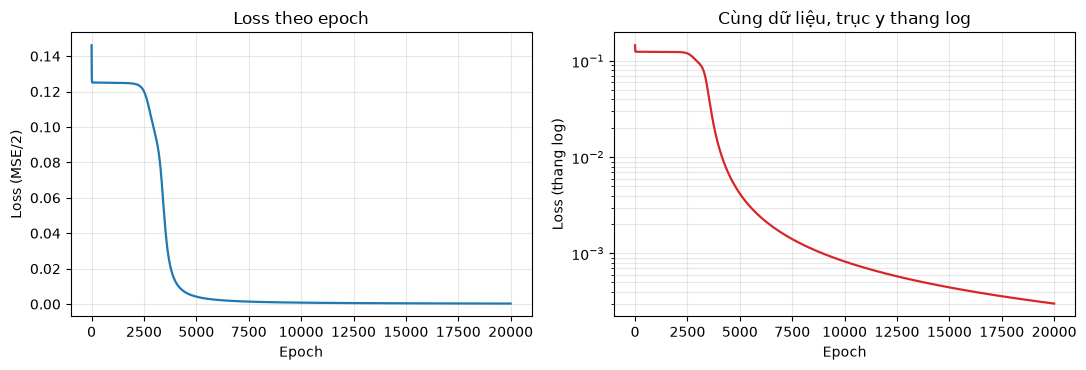

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].plot(kq["loss"], lw=1.6)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (MSE/2)")
axes[0].set_title("Loss theo epoch")
axes[0].grid(alpha=0.3)

axes[1].semilogy(kq["loss"], lw=1.6, c="#d62728")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss (thang log)")
axes[1].set_title("Cùng dữ liệu, trục y thang log")
axes[1].grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

Đường loss có hình chữ L đặc trưng của XOR: một **cao nguyên** ở đầu khi mạng còn dự đoán
xấp xỉ 0.5 cho mọi mẫu, rồi tụt nhanh khi tầng ẩn tìm ra được biểu diễn hữu ích, sau đó
giảm chậm dần. Trục log ở hình phải cho thấy loss vẫn tiếp tục giảm đều dù hình bên trái
trông như đã "phẳng".

In [17]:
du_doan = kq["y_hat"]
bang_kq = pd.DataFrame({
    "x1_tai_cpu": X[:, 0],
    "x2_quat": X[:, 1],
    "y_nhan": y[:, 0],
    "y_hat": du_doan[:, 0].round(4),
    "quyet_dinh (nguong 0.5)": (du_doan[:, 0] >= 0.5).astype(int),
})
bang_kq["dung?"] = np.where(
    bang_kq["quyet_dinh (nguong 0.5)"] == bang_kq["y_nhan"], "✔", "✘")
display(bang_kq)

acc = (bang_kq["quyet_dinh (nguong 0.5)"] == bang_kq["y_nhan"]).mean()
print("Accuracy =", acc)
assert acc == 1.0, "MLP phải phân loại đúng cả 4 mẫu XOR"
print("MLP 2->2->1 giải được XOR — điều Perceptron một tầng không làm được.")

,x1_tai_cpu,x2_quat,y_nhan,y_hat,quyet_dinh (nguong 0.5),dung?
0,0.0,0.0,0.0,0.0235,0,✔
1,0.0,1.0,1.0,0.9735,1,✔
2,1.0,0.0,1.0,0.9737,1,✔
3,1.0,1.0,0.0,0.0213,0,✔


Accuracy = 1.0
MLP 2->2->1 giải được XOR — điều Perceptron một tầng không làm được.


## 11. Tầng ẩn đã học được gì?

Bài giảng đưa ra một cách phân tách XOR thành ba cổng logic:

$$
x_1 \operatorname{XOR} x_2 =
(x_1 \operatorname{OR} x_2) \operatorname{AND} (x_1 \operatorname{NAND} x_2)
$$

Trước hết ta kiểm tra: nếu **tự tay** đặt trọng số theo cách phân tách này, mạng
`2 → 2 → 1` có cho ra XOR không?

In [18]:
def du_doan_mlp(X_moi, tham_so):
    a1 = sigmoid(X_moi @ tham_so["W1"] + tham_so["b1"])
    return sigmoid(a1 @ tham_so["W2"] + tham_so["b2"]), a1


# Tự tay đặt trọng số: h1 = OR, h2 = NAND, output = AND(h1, h2)
# Dùng hệ số lớn (20) để sigmoid gần như trở thành hàm bước
tham_so_thu_cong = {
    "W1": np.array([[20., -20.],      # x1 -> h1 (OR), x1 -> h2 (NAND)
                    [20., -20.]]),    # x2 -> h1 (OR), x2 -> h2 (NAND)
    "b1": np.array([[-10., 30.]]),    # OR: ngưỡng 0.5 | NAND: ngưỡng 1.5
    "W2": np.array([[20.],            # h1 -> out
                    [20.]]),          # h2 -> out
    "b2": np.array([[-30.]]),         # AND: cần cả hai h mới bật
}

diem_tc, a1_tc = du_doan_mlp(X, tham_so_thu_cong)
bang_tc = pd.DataFrame({
    "x1": X[:, 0].astype(int),
    "x2": X[:, 1].astype(int),
    "h1 (kỳ vọng OR)": a1_tc[:, 0].round(3),
    "h2 (kỳ vọng NAND)": a1_tc[:, 1].round(3),
    "y_hat": diem_tc[:, 0].round(3),
    "y_nhãn": y[:, 0].astype(int),
})
display(bang_tc)

acc_tc = ((diem_tc[:, 0] >= 0.5).astype(float) == y[:, 0]).mean()
print("Accuracy của bộ trọng số đặt tay =", acc_tc)
assert acc_tc == 1.0
print("Cách phân tách OR-NAND-AND của bài giảng là một nghiệm hợp lệ.")

,x1,x2,h1 (kỳ vọng OR),h2 (kỳ vọng NAND),y_hat,y_nhãn
0,0,0,0.0,1.0,0.0,0
1,0,1,1.0,1.0,1.0,1
2,1,0,1.0,1.0,1.0,1
3,1,1,1.0,0.0,0.0,0


Accuracy của bộ trọng số đặt tay = 1.0
Cách phân tách OR-NAND-AND của bài giảng là một nghiệm hợp lệ.


Bộ trọng số đặt tay hoạt động đúng. Nhưng **đó không phải nghiệm duy nhất**. Gradient
descent không hề biết đến OR hay NAND; nó chỉ đi theo hướng giảm loss và dừng ở nghiệm
nào gần khởi tạo nhất. Hãy xem mạng đã huấn luyện ở phần 10 thực sự tìm ra cái gì.

In [19]:
a1_da_hoc = kq["a1"]

# 16 hàm logic 2 biến, để dò xem mỗi nơ-ron ẩn tương ứng với cổng nào
x1b, x2b = X[:, 0].astype(bool), X[:, 1].astype(bool)
cac_cong = {
    "FALSE": np.zeros(4, bool),      "TRUE": np.ones(4, bool),
    "x1": x1b,                       "NOT x1": ~x1b,
    "x2": x2b,                       "NOT x2": ~x2b,
    "AND": x1b & x2b,                "NAND": ~(x1b & x2b),
    "OR": x1b | x2b,                 "NOR": ~(x1b | x2b),
    "XOR": x1b ^ x2b,                "XNOR": ~(x1b ^ x2b),
    "x1 -> x2": ~x1b | x2b,          "x2 -> x1": x1b | ~x2b,
    "x1 AND NOT x2": x1b & ~x2b,     "NOT x1 AND x2": ~x1b & x2b,
}


def doan_cong(vector_activation):
    lam_tron = vector_activation.round(0).astype(bool)
    ten = [k for k, v in cac_cong.items() if np.array_equal(lam_tron, v)]
    return ten[0] if ten else "không khớp cổng nào"


bang_an_hoc = pd.DataFrame({
    "x1": X[:, 0].astype(int),
    "x2": X[:, 1].astype(int),
    "h1": a1_da_hoc[:, 0].round(3),
    "h2": a1_da_hoc[:, 1].round(3),
    "y_hat": kq["y_hat"][:, 0].round(3),
})
display(bang_an_hoc)

print("h1 (làm tròn) tương ứng cổng:", doan_cong(a1_da_hoc[:, 0]))
print("h2 (làm tròn) tương ứng cổng:", doan_cong(a1_da_hoc[:, 1]))

h_and = (a1_da_hoc.round(0).astype(bool)[:, 0] & a1_da_hoc.round(0).astype(bool)[:, 1])
print("h1 AND h2 =", h_and.astype(int), "| NOT(h1 AND h2) =", (~h_and).astype(int),
      "| nhãn XOR =", y[:, 0].astype(int))

print("\nW1 (dòng = input, cột = nơ-ron ẩn):\n", np.round(kq["W1"], 3))
print("b1:", np.round(kq["b1"].ravel(), 3))
print("W2 (dòng = nơ-ron ẩn):", np.round(kq["W2"].ravel(), 3))
print("b2:", np.round(kq["b2"].ravel(), 3))

,x1,x2,h1,h2,y_hat
0,0,0,0.959,0.970,0.024
1,0,1,0.043,1.000,0.973
2,1,0,1.000,0.034,0.974
3,1,1,0.967,0.974,0.021


h1 (làm tròn) tương ứng cổng: x2 -> x1
h2 (làm tròn) tương ứng cổng: x1 -> x2
h1 AND h2 = [1 0 0 1] | NOT(h1 AND h2) = [0 1 1 0] | nhãn XOR = [0 1 1 0]

W1 (dòng = input, cột = nơ-ron ẩn):
 [[ 6.476 -6.843]
 [-6.237  6.977]]
b1: [3.143 3.487]
W2 (dòng = nơ-ron ẩn): [-8.271 -8.198]
b2: [12.158]


Kết quả đáng chú ý: với `seed = 42`, mạng **không** học ra cặp (OR, NAND) như bài giảng
gợi ý. Nó tìm ra một cách phân tách khác nhưng tương đương về mặt logic:

- $h_1 \approx (x_2 \rightarrow x_1)$, tức `x1 OR NOT x2`
- $h_2 \approx (x_1 \rightarrow x_2)$, tức `NOT x1 OR x2`
- Tầng ra có $\mathbf{W}^{(2)} \approx [-8.3, -8.2]$ (cả hai **âm**) và $b^{(2)} \approx 12.2$,
  nên nó thực hiện phép **NAND**: đầu ra chỉ bật khi *không phải* cả $h_1$ và $h_2$ đều bật.

Ghép lại: $\text{NOT}(h_1 \text{ AND } h_2)$ đúng bằng XOR — dòng in ra ở trên xác nhận điều này.
Về mặt logic đây chính là hằng đẳng thức $x_1 \oplus x_2 = \lnot\bigl((x_2 \to x_1) \land (x_1 \to x_2)\bigr)$,
vì $h_1 \land h_2$ tương đương XNOR.

Bài học rút ra rất quan trọng và thường bị bỏ qua:

> Bài toán có **nhiều nghiệm**. Cách diễn giải OR/NAND trong bài giảng là *một* nghiệm
> đẹp cho con người, không phải nghiệm mà gradient descent buộc phải tìm ra. Đổi `seed`
> là mạng có thể học ra cặp cổng khác.

Điều **bất biến** qua mọi nghiệm là: hai nơ-ron ẩn chia nhau việc, mỗi nơ-ron cắt mặt
phẳng bằng một đường thẳng, và tầng ra kết hợp hai nửa mặt phẳng đó. Tầng ẩn không sao
chép input mà **học cách biểu diễn lại dữ liệu** để tầng ra chỉ còn phải giải một bài
toán tuyến tính.

Hãy thử đổi `seed` trong phần 10 và chạy lại cell trên để tự kiểm chứng.

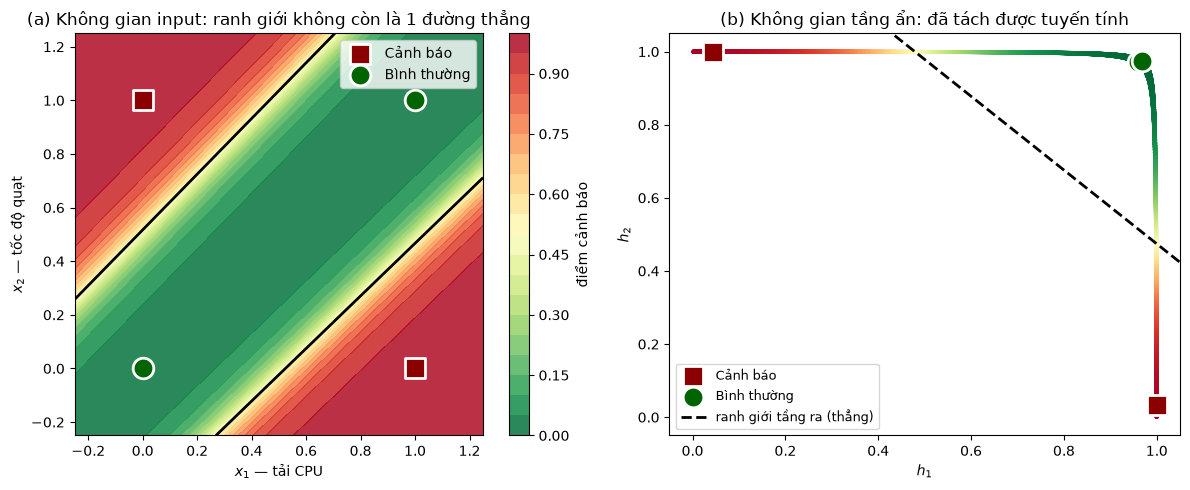

In [20]:
# Lưới điểm để vẽ vùng quyết định
g = np.linspace(-0.25, 1.25, 260)
G1, G2 = np.meshgrid(g, g)
luoi = np.c_[G1.ravel(), G2.ravel()]
diem_luoi, a1_luoi = du_doan_mlp(luoi, kq)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) Không gian input gốc
ct = axes[0].contourf(G1, G2, diem_luoi.reshape(G1.shape),
                      levels=20, cmap="RdYlGn_r", alpha=0.85)
axes[0].contour(G1, G2, diem_luoi.reshape(G1.shape), levels=[0.5],
                colors="black", linewidths=2)
fig.colorbar(ct, ax=axes[0], label="điểm cảnh báo")
mask = y[:, 0] == 1
axes[0].scatter(X[mask, 0], X[mask, 1], s=220, marker="s", c="#8b0000",
                edgecolors="white", lw=2, zorder=3, label="Cảnh báo")
axes[0].scatter(X[~mask, 0], X[~mask, 1], s=220, marker="o", c="#006400",
                edgecolors="white", lw=2, zorder=3, label="Bình thường")
axes[0].set_xlabel("$x_1$ — tải CPU")
axes[0].set_ylabel("$x_2$ — tốc độ quạt")
axes[0].set_title("(a) Không gian input: ranh giới không còn là 1 đường thẳng")
axes[0].legend(loc="upper right")

# (b) Không gian tầng ẩn
axes[1].scatter(a1_luoi[:, 0], a1_luoi[:, 1], s=3,
                c=diem_luoi.ravel(), cmap="RdYlGn_r", alpha=0.35)
_, a1_mau = du_doan_mlp(X, kq)
axes[1].scatter(a1_mau[mask, 0], a1_mau[mask, 1], s=220, marker="s", c="#8b0000",
                edgecolors="white", lw=2, zorder=3, label="Cảnh báo")
axes[1].scatter(a1_mau[~mask, 0], a1_mau[~mask, 1], s=220, marker="o", c="#006400",
                edgecolors="white", lw=2, zorder=3, label="Bình thường")

# Ranh giới của tầng ra trong không gian ẩn là một ĐƯỜNG THẲNG: W2·h + b2 = 0
w2 = kq["W2"].ravel()
b2_hoc = kq["b2"].item()
h1_line = np.linspace(-0.05, 1.05, 50)
if abs(w2[1]) > 1e-9:
    h2_line = -(w2[0] * h1_line + b2_hoc) / w2[1]
    axes[1].plot(h1_line, h2_line, "k--", lw=2, label="ranh giới tầng ra (thẳng)")
axes[1].set_xlim(-0.05, 1.05)
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_xlabel("$h_1$")
axes[1].set_ylabel("$h_2$")
axes[1].set_title("(b) Không gian tầng ẩn: đã tách được tuyến tính")
axes[1].legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()

Hình (a) cho thấy điều Perceptron không làm được: ranh giới quyết định trong không gian
input gốc là một đường **cong**, tách được hai góc chéo.

Hình (b) là lời giải thích: sau khi qua tầng ẩn, bốn điểm được di chuyển sang vị trí mới,
nơi một **đường thẳng** duy nhất (chính là ranh giới của tầng ra) đã tách được hai lớp.
Tầng ẩn làm phần việc "bóp méo không gian", tầng ra chỉ việc kẻ một đường thẳng.

## 12. Thí nghiệm: learning rate và số nơ-ron ẩn

Bài giảng yêu cầu thử ít nhất ba learning rate. Ta thử luôn bốn giá trị
`0.1, 0.5, 1.0, 5.0` với cùng seed để so sánh công bằng.

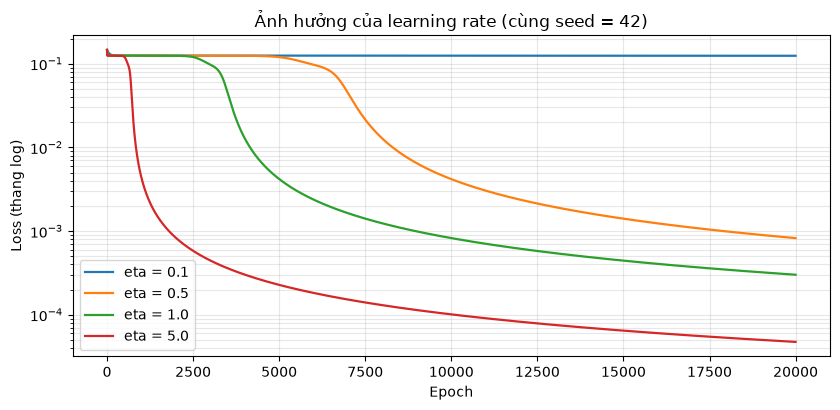

,eta,loss cuối,epoch đạt loss < 0.01,accuracy
0,0.1,0.124450,NaN,0.5
1,0.5,0.000824,8297.0,1.0
2,1.0,0.000301,4154.0,1.0
3,5.0,0.000047,840.0,1.0


In [21]:
cac_eta = [0.1, 0.5, 1.0, 5.0]
ket_qua_eta = {}

fig, ax = plt.subplots(figsize=(8.5, 4.2))
for e in cac_eta:
    r = huan_luyen_mlp(X, y, so_an=2, eta=e, so_epoch=20000, seed=42, ghi_log_moi=0)
    ket_qua_eta[e] = r
    ax.semilogy(r["loss"], lw=1.6, label=f"eta = {e}")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (thang log)")
ax.set_title("Ảnh hưởng của learning rate (cùng seed = 42)")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.tight_layout()
plt.show()

bang_eta = pd.DataFrame([{
    "eta": e,
    "loss cuối": r["loss"][-1],
    "epoch đạt loss < 0.01": (int(np.argmax(r["loss"] < 0.01))
                              if (r["loss"] < 0.01).any() else None),
    "accuracy": ((r["y_hat"][:, 0] >= 0.5).astype(float) == y[:, 0]).mean().item(),
} for e, r in ket_qua_eta.items()])
display(bang_eta)

Đọc kết quả:

- `eta = 0.1`: quá nhỏ. Sau 20000 epoch loss vẫn ở mức 0.124 và accuracy chỉ 0.5 — mạng
  **chưa thoát khỏi cao nguyên** ban đầu, vẫn dự đoán xấp xỉ 0.5 cho mọi mẫu.
- `eta = 0.5` và `1.0`: học ổn định, hội tụ tốt.
- `eta = 5.0`: hội tụ **nhanh nhất** ở bài toán tí hon này vì bề mặt loss rất đơn giản.
  Đừng rút ra kết luận sai rằng "learning rate càng lớn càng tốt": với dữ liệu thật,
  learning rate lớn thường làm loss dao động hoặc phân kỳ. Muốn thấy hiện tượng đó, hãy
  thử `eta = 50` ở phần bài tập.

Tiếp theo, thử số nơ-ron ẩn.

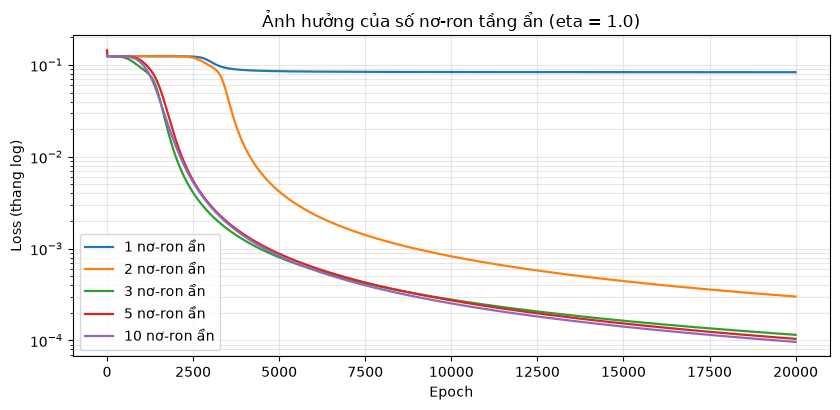

,số nơ-ron ẩn,số tham số,loss cuối,accuracy
0,1,5,0.083591,0.75
1,2,9,0.000301,1.00
2,3,13,0.000115,1.00
3,5,21,0.000104,1.00
4,10,41,0.000096,1.00


In [22]:
cac_so_an = [1, 2, 3, 5, 10]
dong = []

fig, ax = plt.subplots(figsize=(8.5, 4.2))
for h in cac_so_an:
    r = huan_luyen_mlp(X, y, so_an=h, eta=1.0, so_epoch=20000, seed=42, ghi_log_moi=0)
    ax.semilogy(r["loss"], lw=1.6, label=f"{h} nơ-ron ẩn")
    dong.append({
        "số nơ-ron ẩn": h,
        "số tham số": h * 2 + h + h + 1,
        "loss cuối": r["loss"][-1],
        "accuracy": ((r["y_hat"][:, 0] >= 0.5).astype(float) == y[:, 0]).mean().item(),
    })

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (thang log)")
ax.set_title("Ảnh hưởng của số nơ-ron tầng ẩn (eta = 1.0)")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.tight_layout()
plt.show()

display(pd.DataFrame(dong))

Với **1 nơ-ron ẩn**, mạng `2 → 1 → 1` vẫn chỉ tạo được một ranh giới tuyến tính nên
không giải được XOR — loss kẹt lại và accuracy không đạt 1.0. Từ **2 nơ-ron ẩn** trở lên
mạng giải được; nhiều nơ-ron hơn thì hội tụ nhanh hơn nhưng không cần thiết cho bài toán
này. Hai nơ-ron là **số tối thiểu đủ dùng**, và cũng là cấu hình dễ diễn giải nhất.

## 13. Thử mô hình trên tình huống liên tục

Phiên bản nhị phân chỉ để giảng nguyên lý. Thử đưa vào các giá trị trung gian (ví dụ CPU
70%, quạt 30% tốc độ tối đa) xem mô hình phản ứng thế nào — mặc dù nó **chưa từng thấy**
dữ liệu dạng này khi huấn luyện.

In [23]:
tinh_huong_moi = np.array([
    [0.2, 0.1],   # CPU 20%, quạt gần như đứng
    [0.2, 0.9],   # CPU 20%, quạt gào rất to
    [0.95, 0.1],  # CPU 95%, quạt vẫn chậm
    [0.95, 0.9],  # CPU 95%, quạt nhanh
    [0.5, 0.5],   # đúng ở giữa, mô hình khó xử
    [0.7, 0.3],   # CPU khá cao, quạt khá chậm
])
mo_ta = [
    "CPU 20%, quạt gần đứng",
    "CPU 20%, quạt rất nhanh",
    "CPU 95%, quạt vẫn chậm",
    "CPU 95%, quạt nhanh",
    "Cả hai ở mức giữa",
    "CPU 70%, quạt 30%",
]

diem, _ = du_doan_mlp(tinh_huong_moi, kq)
bang_moi = pd.DataFrame({
    "tình huống": mo_ta,
    "x1_tai_cpu": tinh_huong_moi[:, 0],
    "x2_quat": tinh_huong_moi[:, 1],
    "điểm cảnh báo": diem[:, 0].round(3),
    "kết luận": np.where(diem[:, 0] >= 0.5, "CẢNH BÁO", "bình thường"),
})
display(bang_moi)

,tình huống,x1_tai_cpu,x2_quat,điểm cảnh báo,kết luận
0,"CPU 20%, quạt gần đứng",0.20,0.1,0.025,bình thường
1,"CPU 20%, quạt rất nhanh",0.20,0.9,0.882,CẢNH BÁO
2,"CPU 95%, quạt vẫn chậm",0.95,0.1,0.959,CẢNH BÁO
3,"CPU 95%, quạt nhanh",0.95,0.9,0.022,bình thường
4,Cả hai ở mức giữa,0.50,0.5,0.022,bình thường
5,"CPU 70%, quạt 30%",0.70,0.3,0.151,bình thường


Bốn tình huống gần các góc cho kết quả hợp trực giác. Nhưng hai dòng cuối bộc lộ một vấn
đề thật:

- `(0.5, 0.5)` — CPU và quạt đều ở mức giữa — cho điểm cảnh báo **0.022**, tức mô hình
  rất *tự tin* rằng bình thường. Nó không hề "do dự" dù chưa bao giờ thấy mẫu nào ở giữa.
- `(0.7, 0.3)` — CPU khá cao mà quạt khá chậm, trực giác là **nên** cảnh báo — chỉ được
  0.151, tức bị xếp vào bình thường.

Nguyên nhân: mạng chỉ được học 4 điểm ở 4 góc, và trọng số đã lớn (khoảng ±7) nên sigmoid
bị **bão hoà** — đầu ra bị đẩy về gần 0 hoặc gần 1 ở hầu hết mọi nơi. Mô hình không có
cách nào biết rằng vùng giữa là vùng nó nên "không chắc".

Bài học: **điểm số cao của sigmoid không phải là độ tin cậy.** Ngoài miền dữ liệu huấn
luyện, mô hình vẫn trả lời dứt khoát nhưng không có căn cứ. Đây là minh hoạ trực tiếp cho
giới hạn của ví dụ sư phạm này — muốn dùng thật, phải huấn luyện trên dữ liệu liên tục
thực tế, và không nên coi điểm số của mô hình là kết luận kỹ thuật cuối cùng.

## 14. Bài tập

Sinh viên hoàn thiện các TODO dưới đây. Mỗi bài đều có thể kiểm tra bằng `assert` hoặc
bằng cách đối chiếu với kết quả đã in ở trên.

**Bài 1 — Tính tay mẫu khác.** Lặp lại phần 4 và 6–8 nhưng với mẫu `x = [0, 1]`, `y = 1` và
cùng bộ trọng số khởi tạo. Dự đoán trước: cột nào của `dW1` sẽ bằng 0? Vì sao?

**Bài 2 — Loss BCE.** Thay MSE bằng binary cross-entropy
$L = -[y\log\hat y + (1-y)\log(1-\hat y)]$. Khi đó $\delta^{(2)} = \hat y - y$ (hệ số
$\hat y(1-\hat y)$ bị triệt tiêu). Cài đặt và so sánh tốc độ hội tụ với MSE.

**Bài 3 — Learning rate quá lớn.** Chạy với `eta = 50` và `eta = 200`. Loss có dao động
hay phân kỳ không? Vẽ loss curve minh chứng.

**Bài 4 — ReLU ở tầng ẩn.** Đổi activation tầng ẩn thành ReLU
($\text{relu}(z) = \max(0, z)$, đạo hàm là `(z > 0)`), giữ sigmoid ở tầng ra. So sánh số
epoch cần thiết.

**Bài 5 — SGD từng mẫu.** Sửa `huan_luyen_mlp` thành cập nhật sau **mỗi mẫu** (stochastic)
thay vì full-batch. Loss curve khác thế nào?

**Bài 6 — Nghiệm không duy nhất.** Chạy lại phần 10 với `seed = 0, 1, 7, 123` rồi dùng
hàm `doan_cong` ở phần 11 để xem mỗi lần mạng học ra cặp cổng logic nào. Lập bảng tổng
hợp. Có seed nào cho ra đúng cặp (OR, NAND) như bài giảng không?

In [24]:
# ============ BÀI 1: tính tay cho mẫu x = [0, 1], y = 1 ============
x_b1 = np.array([[0.0],
                 [1.0]])
t_b1 = 1.0

# Dùng lại đúng bộ trọng số khởi tạo của bài giảng
W1_b1 = np.array([[0.1, 0.2], [0.3, 0.4]])
b1_b1 = np.array([[0.1], [-0.1]])
W2_b1 = np.array([[0.5, -0.5]])
b2_b1 = np.array([[0.1]])

# TODO 1: forward — tính z1, a1, z2, y_hat, L
# z1_b1 = ...
# a1_b1 = ...
# z2_b1 = ...
# yhat_b1 = ...
# L_b1 = ...

# TODO 2: backward tầng ra — delta2, dW2, db2

# TODO 3: backward tầng ẩn — delta1, dW1, db1

# TODO 4: cập nhật với eta = 0.5, rồi kiểm tra loss có giảm không

# Gợi ý kiểm tra: cột ĐẦU TIÊN của dW1 phải bằng 0 vì x1 = 0.

In [25]:
# ============ BÀI 2: đổi sang binary cross-entropy ============
def huan_luyen_mlp_bce(X, y, so_an=2, eta=1.0, so_epoch=20000, seed=42):
    rng = np.random.default_rng(seed)
    m, n_input = X.shape
    W1 = rng.normal(0, 0.5, size=(n_input, so_an))
    b1 = np.zeros((1, so_an))
    W2 = rng.normal(0, 0.5, size=(so_an, 1))
    b2 = np.zeros((1, 1))
    lich_su = []

    for _ in range(so_epoch):
        z1 = X @ W1 + b1
        a1 = sigmoid(z1)
        z2 = a1 @ W2 + b2
        y_hat = np.clip(sigmoid(z2), 1e-12, 1 - 1e-12)   # tránh log(0)

        # TODO 1: tính loss BCE, lưu vào biến `loss`
        loss = 0.0          # <-- thay bằng công thức BCE
        lich_su.append(loss)

        # TODO 2: với BCE + sigmoid, delta2 rút gọn thành gì?
        delta2 = np.zeros_like(y_hat)   # <-- thay bằng công thức đúng

        dW2 = a1.T @ delta2 / m
        db2 = delta2.mean(axis=0, keepdims=True)
        delta1 = (delta2 @ W2.T) * a1 * (1 - a1)
        dW1 = X.T @ delta1 / m
        db1 = delta1.mean(axis=0, keepdims=True)

        W2 -= eta * dW2
        b2 -= eta * db2
        W1 -= eta * dW1
        b1 -= eta * db1

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2,
            "loss": np.array(lich_su), "y_hat": y_hat}


# Sau khi hoàn thiện TODO, bỏ comment hai dòng sau:
# kq_bce = huan_luyen_mlp_bce(X, y, eta=1.0, so_epoch=20000)
# print("Loss BCE cuối =", kq_bce["loss"][-1], "| y_hat =", kq_bce["y_hat"].ravel().round(4))

## 15. Câu hỏi thảo luận

1. Vì sao trường hợp CPU cao và quạt nhanh **không** bị cảnh báo?
2. Vì sao CPU thấp nhưng quạt nhanh lại có thể là bất thường?
3. Vì sao một Perceptron không giải được bảng dữ liệu này? Hãy nêu lại bằng ngôn ngữ hình học.
4. Tầng ẩn thay đổi biểu diễn dữ liệu như thế nào? Đối chiếu với hình (b) ở phần 11.
5. Vì sao gradient của một số trọng số bằng 0 khi input tương ứng bằng 0? Bias có bị như vậy không?
6. Vì sao phải dùng $\mathbf{W}^{(2)}$ **trước cập nhật** để tính $\boldsymbol{\delta}^{(1)}$?
7. Backpropagation khác gradient descent ở điểm nào? (Gợi ý: một cái *tính* gradient, một cái *dùng* gradient.)
8. Điều gì xảy ra nếu learning rate quá lớn? Kết quả phần 12 có làm bạn ngạc nhiên không?
9. Nếu quạt quay nhanh vì người dùng bật chế độ làm mát thủ công, mô hình có cảnh báo sai không? Sửa thế nào?
10. Cần thêm đặc trưng nào để mô hình thực tế hơn?
11. Ở phần 11, mạng học ra cặp cổng logic khác với bài giảng nhưng vẫn đúng. Điều này nói gì về tính duy nhất của nghiệm?
12. Ở phần 13, vì sao mô hình rất "tự tin" ở điểm `(0.5, 0.5)` dù chưa từng thấy mẫu nào ở giữa?

## 16. Từ ví dụ sư phạm sang hệ thống thật

| Đặc trưng | Kiểu dữ liệu | Ví dụ |
|---|---|---|
| Tải CPU | Liên tục | 0–100% |
| Nhiệt độ CPU | Liên tục | 30–100°C |
| Tốc độ quạt | Liên tục | RPM |
| Sử dụng bộ nhớ | Liên tục | 0–100% |
| Công suất tiêu thụ | Liên tục | Watt |
| Chế độ quạt thủ công | Nhị phân | 0 / 1 |

Quy trình triển khai: thu thập dữ liệu cảm biến → làm sạch và chuẩn hoá → chia
train/validation/test → xây MLP → huấn luyện bằng backpropagation → đánh giá precision,
recall, confusion matrix → chọn ngưỡng cảnh báo → kiểm thử trên thiết bị thật.

### Giới hạn của ví dụ này

- Hai tín hiệu nhị phân là mô hình đơn giản hoá mạnh.
- Quạt nhanh khi CPU thấp chưa chắc là lỗi: có thể do GPU, nhiệt độ phòng, hoặc cấu hình thủ công.
- CPU cao và quạt nhanh vẫn có thể quá nhiệt nếu bộ tản nhiệt hỏng.
- Mô hình thật cần cảm biến nhiệt độ và dữ liệu theo thời gian.
- Không nên xem output mô hình là kết luận kỹ thuật cuối cùng; cần kết hợp ngưỡng an toàn và quy tắc hệ thống.
- Chỉ có 4 mẫu huấn luyện nên không có tập test; mọi con số accuracy ở đây là trên chính tập huấn luyện.
- Sigmoid bão hoà làm mô hình trả lời dứt khoát cả ở vùng chưa từng học (phần 13); điểm số đầu ra **không** phải độ tin cậy.
- Bài toán có nhiều nghiệm tương đương; cách diễn giải logic của tầng ẩn phụ thuộc vào khởi tạo.

## 17. Nội dung cần ghi nhớ

- **Forward propagation:** tạo dự đoán từ input, và **lưu lại** các giá trị trung gian.
- **Loss:** đo mức sai khác giữa dự đoán và nhãn.
- **Backpropagation:** dùng quy tắc dây chuyền để tính gradient của loss theo từng tham số.
- **Gradient descent:** dùng gradient đó để cập nhật tham số.
- **Tầng ẩn:** học biểu diễn trung gian, biến bài toán phi tuyến thành tuyến tính ở tầng ra.
- **XOR:** ví dụ nhỏ nhất chứng minh một Perceptron không đủ.

> Dự đoán đi xuôi, sai số đi ngược; trọng số được sửa để lần dự đoán tiếp theo tốt hơn.

## Nguồn tham khảo

- Stanford CS231n, *Backpropagation and Neural Networks*: https://cs231n.stanford.edu/
- PyTorch, *The Fundamentals of Autograd*: https://docs.pytorch.org/tutorials/beginner/introyt/autogradyt_tutorial.html
- Goodfellow, Bengio, Courville, *Deep Learning*, Chương 6: https://www.deeplearningbook.org/contents/mlp.html